# DAI Mission — Proposal Template
**Data & AI in Economics | TU Dortmund**

This notebook is your team's mission proposal. Fill in every section before submission. Once approved, you will extend this same notebook into your final deliverable.

> **Team size:** 2–3 students  
> **Deliverable:** This Jupyter Notebook (proposal → final submission in one file)


## 1. Team

| Role | Name | Student ID |
|------|------|------------|
| Lead |Angel Gomez | |
| Member |Kevin Cazzolato |277485|
| Member *(optional)* | Berk Bahar | |


## 2. Mission Title & Research Question

**Title:** *How Trade Policy Uncertainty Regimes Reshape Stock Sector Network Structure*

**Research question:** *How does Trade Policy Uncertainty (TPU) alter the correlation structure and directional interdependencies across US stock market sectors, and which sectors emerge as central nodes or isolated absorbers during high-uncertainty regimes, as identified through the 2025 tariff events?*

**Why it matters:** *Noramlly the TPU is as an isolated risk factor that shifts return distributions or elevates volatility at the individual asset level. This project addresses a structural gap: whether high trade uncertainty actively reconfigures the network of interdependencies between equity sectors, changing not just how much risk exists, but how it propagates. By combining latent regime detection with network analysis, we move beyond unconditional correlations and ask whether trade-sensitive sectors — such as Technology, Industrials, or Consumer Discretionary — systematically become more central or more isolated during periods of elevated policy uncertainty. The answer has direct implications for systemic risk monitoring and regime-aware portfolio construction.*

## 3. Data

**Source(s):**
* **Trade Policy Uncertainty:** Economic Policy Uncertainty (EPU) database (Baker, Bloom, and Davis index) and/or the Federal Reserve Board (Caldara et al. index).
* **Financial Data:** CRSP (Center for Research in Security Prices), Bloomberg, or Yahoo Finance for adjusted daily closing prices and volumes of sector ETFs.
* **Policy Timeline:** Office of the United States Trade Representative (USTR) and the Federal Register for the qualitative timeline of the 2025 tariff events (China, Canada, Mexico).
* **Macro Controls:** FRED (Federal Reserve Economic Data) for the VIX and other broader market indicators.

**Unit of observation:**
The primary unit of observation is the daily trading period. For the network analysis, the cross-sectional units are the 11 US Select Sector SPDR ETFs (e.g., XLK for Technology, XLI for Industrials), observed synchronously over time to capture both contemporaneous and lagged interdependencies.

**Key variables:**
* **State Variable:** The continuous TPU Index, which will be fed into the Hidden Markov Model (HMM) to estimate the latent categorical variable (the regimes, e.g., "Low TPU" vs. "High TPU").
* **Endogenous Network Variables:** Daily log-returns and realized volatilities of the 11 sector ETFs.
* **Derived Network Metrics:** Pairwise correlation and partial correlation matrices computed per regime, node-level centrality measures (degree, betweenness), and pairwise Granger causality statistics to capture directional interdependencies between sectors.
* **Control Variables:** The CBOE Volatility Index (VIX) to capture general market risk aversion, S&P 500 aggregate returns, and interest rate spreads to isolate trade shocks from broad macroeconomic shocks.

**Potential data quality issues:**
* **Frequency Mismatch & Timing:** News-based TPU indices may react with a slight delay or advance compared to financial markets. Aligning daily text-based indices with precise daily market closes requires careful handling to avoid look-ahead bias.
* **Noise in Text-Based Indices:** The Baker, Bloom, and Davis TPU index relies on algorithmic newspaper scraping. This can occasionally generate false positives (e.g., articles discussing historical trade routes rather than current policy uncertainty), introducing noise into the HMM regime estimation.
* **Confounding Macro Shocks:** The 2025 tariff measures likely coincide with other systemic developments (e.g., central bank rate decisions, inflation reports). Failing to properly control for general market volatility (via the VIX) could lead to attributing general market panic exclusively to trade policy.
* **Non-Stationarity:** Both financial time series and continuous indices often exhibit non-stationarity. Careful pre-processing (e.g., utilizing log-returns, first differences, or structural break tests) is required before estimating network metrics to ensure they do not reflect spurious correlations.
* **Look-Ahead Bias & Publication Lag:** Many macroeconomic and policy-based variables are published with a delay relative to the period they describe, or are subsequently revised. For example, the Baker, Bloom, and Davis TPU index is constructed from newspaper archives and may not be available in real time on the reference date; similarly, FRED macro variables such as interest rate spreads are often subject to revision. To prevent data leakage in all supervised learning models, we strictly apply a **publication lag adjustment**: each variable is only made available to the model as of the date it was *publicly released*, not the date it describes. Concretely, this means aligning all features using a conservative lag of at least one trading day between the information release date and its use as a predictor, and never allowing any future information to enter the feature set of a past observation.

In [3]:
import sys
from pathlib import Path

# main.ipynb è nella root della repo → src/ è direttamente sotto
SRC_DIR = Path.cwd() / "src"
sys.path.insert(0, str(SRC_DIR))

from data_acquisition import DataPipeline

pipeline = DataPipeline(start_date="2018-01-01", end_date="2026-06-18")
log_returns, log_prices, macro_raw, tpu_raw, master = pipeline.run_pipeline()

📥 Download ETF prices from Yahoo Finance...
✓ yfinance loaded — 2126 trading days
  Date range  : 2018-01-02 → 2026-06-17
  Price matrix: (2126, 11)
               XLK     XLI     XLY    XLF     XLV    XLE    XLB   XLRE    XLU  \
Date                                                                            
2026-06-15  191.79  178.68  118.57  53.56  152.89  55.55  52.50  44.99  44.74   
2026-06-16  186.44  179.85  118.46  54.35  152.94  55.36  52.72  45.10  45.06   
2026-06-17  185.80  179.60  115.49  54.05  150.71  54.67  52.02  43.97  44.46   

              XLP     XLC  
Date                       
2026-06-15  85.48  112.19  
2026-06-16  85.59  112.32  
2026-06-17  83.68  109.20  

Log-returns : (2009, 11)
             XLK        XLI        XLY        XLF        XLV        XLE  \
count  2009.0000  2009.0000  2009.0000  2009.0000  2009.0000  2009.0000   
mean      0.0009     0.0005     0.0004     0.0004     0.0004     0.0004   
std       0.0168     0.0135     0.0151     0.0148     

### ADF tests — stationarity

- **Log-returns (ETFs)**: all stationary (p-value ≈ 0). Expected — financial returns
  fluctuate around a constant mean with no trend. Ready for models that require
  stationarity (HMM, Granger causality networks, supervised learning).
- **Log-prices (ETFs)**: all show a unit root (high p-value). Expected — price levels
  follow a random walk. Use only for cointegration / VECM analysis, not for models
  that assume stationarity.
- **VIX**: stationary in levels. Plausible — VIX shows volatility clustering but
  reverts to a long-run mean.
- **10y-2y spread, DFF, TPU**: all show a unit root in levels, but are **stationary
  in first differences** (Δ p-value ≈ 0). Classic pattern for I(1) macro/rate series.
  If a stationary feature is needed, use first differences instead of levels.

### Missing values

- Only the `*_rvol` columns show NaNs (~1% of rows), concentrated in the first
  21 trading days: this is the warmup required to compute the 21-day rolling
  volatility. **This is not a data error.**
- For models using the full `master_dataset.csv`, these initial rows will have
  NaNs in the `_rvol` columns — handle with `dropna()` or `fillna()` depending
  on the model.
- For models that depend on realized volatility, start from `warmup_end`
  (printed at runtime) to get the full dataset with no NaNs.
- TPU has 100% coverage over the period, no data availability issues.

The datasets ready in `data/` are:
- `log_returns.csv` → models on stationary returns (HMM, networks, supervised learning)
- `log_prices.csv` → cointegration / VECM
- `realized_vol.csv` → volatility feature (mind the warmup period)
- `master_dataset.csv` → full aligned dataset with 1-day publication lag on macro/TPU



## 4. Planned Methods

## 4a. Causal Inference
- [x] Causal graph / DAG (DoWhy)
- [x] Backdoor adjustment
- [ ] Instrumental variable
- [ ] Propensity score stratification
- [x] Other: Granger causality networks (pairwise, per regime) with Benjamini-Hochberg FDR correction

*Justification:*  
We will use a causal graph (DAG) to explicitly model the assumed relationships between Trade Policy Uncertainty (TPU), macro-financial conditions, sectoral returns, and inter-sector network structure. The purpose is to formalize identifying assumptions and clarify potential confounders, rather than to claim strong structural causality in a strict econometric sense.

**DAG Structure & Confounders:**  
A central challenge in identifying the causal effect of TPU on sector network structure is the presence of *simultaneous confounders* — variables that independently affect both TPU and sectoral returns, and therefore threaten to produce spurious associations if left unadjusted. In particular:

- The **VIX** (CBOE Volatility Index) reflects broad market risk aversion. A spike in the VIX can simultaneously elevate perceived policy uncertainty *and* compress sector returns across the board, creating a spurious correlation between TPU and network restructuring that is in fact driven by general market panic.
- **Interest rate spreads** capture macroeconomic stress conditions that can coincide with trade policy episodes (e.g., tightening cycles during inflationary periods driven partly by tariff pass-through), again confounding the TPU–sector relationship.

These variables are explicitly represented in the DAG as common causes of both the TPU state variable and the sector return outcomes. Their confounding paths must be blocked before any causal claim about TPU's effect on network structure can be made.

**Backdoor Adjustment:**  
To isolate the exogenous component of TPU shocks from broader market panic, we apply the **backdoor adjustment criterion** (Pearl, 2009). The adjustment set includes the VIX and interest rate spreads, which satisfy the backdoor criterion relative to the TPU → sector network path: they block all non-causal backdoor paths without conditioning on any descendant of TPU. Concretely, all regime-conditional network metrics (correlations, Granger edges, centrality measures) are estimated after partialling out the contemporaneous influence of VIX and interest rate spreads, ensuring that observed network restructuring across TPU regimes reflects genuine trade policy effects rather than confounded macro-financial noise.

**Multiple Testing Correction:**  
Estimating pairwise Granger causality across 11 sectors yields 110 separate statistical tests per regime (11 × 10 directed pairs). At a standard significance level of α = 0.05, approximately 5–6 spurious edges would be expected purely by chance, which could substantially distort the inferred network topology. To control for this, we apply the **Benjamini-Hochberg (BH) False Discovery Rate (FDR)** correction to all p-values within each regime before defining network edges. An edge is retained only if its BH-adjusted p-value falls below the chosen FDR threshold (q = 0.05), ensuring the resulting network reflects statistically robust directional dependencies rather than noise-driven artifacts.

**Limitations:**  
We acknowledge that our DAG encodes assumptions that are not fully testable from observational data alone. In particular, we cannot rule out the existence of unmeasured confounders (e.g., geopolitical sentiment, investor positioning) that lie outside our adjustment set. Results should therefore be interpreted as evidence of robust conditional associations under the stated identifying assumptions, rather than as proof of structural causation.

---

## 4b. Supervised Learning
- [x] Linear / Ridge / Lasso regression
- [x] Logistic regression
- [ ] k-Nearest Neighbors
- [ ] Support Vector Machine
- [x] Neural network (regression or classification)
- [ ] Other: ___

*Justification:*  
The supervised learning component focuses on predicting directional market outcomes at the sector level, specifically whether future weekly returns are positive or negative.

Logistic regression and regularized linear models (Ridge/Lasso) will serve as baseline models due to their interpretability and robustness in high-noise financial environments. These models will help quantify the marginal predictive contribution of key variables, including TPU regime indicators derived from the HMM, lagged returns, volatility measures, and network centrality features derived from the regime-conditional correlation and Granger networks.

A neural network will be implemented to capture potential nonlinear interactions between TPU regimes and market variables. In particular, the effect of macro uncertainty may be state-dependent — the same signal (e.g., a volatility spike or sector momentum) can have different predictive implications depending on whether the system is in a high- or low-TPU regime. The neural network allows for flexible functional forms to model these interactions, while performance will be carefully benchmarked against simpler models to avoid overfitting.

**Look-Ahead Bias Prevention:**  
A critical requirement for the validity of all supervised learning models is the strict prevention of look-ahead bias. Since our feature set combines financial market data with macroeconomic indices and policy variables — which are often published with a lag or subject to revision — we enforce the following rules throughout the pipeline:

1. **Publication-date alignment:** Every feature is timestamped by its *release date*, not its reference date. For instance, a TPU index value describing week *t* but published on day *t+2* is only used as a predictor from day *t+2* onward.
2. **Forward-only cross-validation:** All time-series cross-validation is performed using an **expanding window** or **walk-forward** scheme, ensuring that the model trained on data up to time *t* is always evaluated on data strictly after *t*. Standard k-fold cross-validation is explicitly excluded, as it allows future observations to contaminate the training set.
3. **Feature construction discipline:** All lagged returns, volatility estimates, network centrality metrics, and HMM regime labels used as features are computed exclusively from information available at prediction time, with no forward-looking smoothing or normalization applied across the full sample.

---

## 4c. Unsupervised Learning / Generative Models
- [x] K-Means clustering
- [x] Hierarchical clustering
- [x] Hidden Markov Model (HMM)
- [x] Other: Cointegration analysis (Johansen test / VECM), TVTP-HMM

*Justification:*  
A Hidden Markov Model (HMM) will be used to identify latent regimes of Trade Policy Uncertainty based on the dynamics of the TPU index and associated financial market variables (e.g., volatility and returns). These regimes represent distinct macro-financial states in which the network structure of equity sector interdependencies may differ structurally.

K-Means clustering will be used as a complementary, non-temporal benchmark to group market conditions based on features such as returns, volatility, and volume, providing a simple comparison against the regime structure identified by the HMM.

Hierarchical clustering will further be used to explore whether sectoral behavior naturally groups into stable clusters across time, potentially revealing persistent similarity structures between sectors that are invariant or regime-dependent.

**Time-Varying Transition Probabilities (TVTP-HMM):**  
A standard HMM assumes that the probability of switching between latent regimes is governed by a *fixed* transition matrix, implying that the likelihood of entering a stress regime is constant regardless of prevailing market conditions. This assumption is economically restrictive and empirically implausible.

To relax it, we extend the baseline HMM to a **Time-Varying Transition Probability (TVTP)** specification, following Filardo (1994) and Diebold, Lee & Weinbach (1994). In the TVTP framework, the transition matrix is a function of an observable conditioning variable at each point in time:

$$P(\text{regime}_{t+1} = j \mid \text{regime}_t = i,\, z_t) = \frac{\exp(\alpha_{ij} + \beta_{ij} z_t)}{1 + \exp(\alpha_{ij} + \beta_{ij} z_t)}$$

where $z_t$ is set equal to the **VIX**: spikes in market-implied volatility signal elevated risk aversion, conditions under which trade policy shocks are more likely to trigger or sustain a high-TPU regime. The TVTP-HMM will be evaluated against the standard HMM using AIC/BIC and a log-likelihood ratio test. A positive and significant $\beta$ for the low-to-high transition would confirm that VIX spikes meaningfully increase the probability of entering a high-TPU regime. The resulting smoothed regime probabilities will replace or augment the fixed-transition HMM labels as inputs to the supervised learning models in Section 4b.

**Cointegration Analysis:**  
Working exclusively with log-returns — while necessary to ensure stationarity for short-term network estimation — comes at a cost: differencing prices destroys long-run equilibrium relationships between sectors that may be economically meaningful, particularly during sustained trade policy stress periods.

To recover this long-run dimension, we complement the returns-based analysis with a **cointegration analysis** at the level of log-prices. We apply the **Johansen cointegration test** to the vector of 11 sector ETF log-prices to determine the number of statistically significant cointegrating vectors, reporting both the trace statistic and maximum eigenvalue statistic. Where cointegration is detected, we estimate a **Vector Error Correction Model (VECM)** to jointly capture short-run dynamics and the speed of adjustment toward long-run equilibrium. Both the Johansen test and the VECM are estimated **separately per TPU regime**: a finding that high-TPU regimes exhibit fewer or weaker cointegrating vectors would suggest that sustained trade shocks fracture long-run sectoral equilibria, not just short-term co-movement. The cointegration results serve as a structural complement to the Granger causality networks — while the latter capture directional predictability over short horizons, the VECM captures equilibrium correction dynamics over longer horizons.



## 5. Evaluation Strategy

*How will you know if your mission succeeded? Describe:*

The mission will be considered successful if it demonstrates that Trade Policy Uncertainty (TPU) is not only associated with changes in individual sector returns, but also induces a statistically and economically meaningful reconfiguration of the cross-sector correlation and dependency network.

First, we expect the Hidden Markov Model (HMM) to identify distinct and economically interpretable regimes of TPU, where high-uncertainty regimes align with known historical trade policy stress periods. The validity of the regime classification will be assessed by its stability, persistence properties, and its alignment with major trade-related events.

Second, the sectoral network analysis should show clear structural differences across regimes. In particular, we expect that the topology of interdependencies (based on correlation networks and pairwise Granger causality) will differ significantly between low- and high-TPU states. This includes measurable changes in network density, centrality measures, and the identity of sectors occupying central versus peripheral positions.

Third, we aim to identify a subset of sectors that systematically emerge as highly connected nodes during high-TPU regimes. The success of this step will be evaluated by the consistency of these roles across time and their economic interpretability (e.g., trade-exposed sectors such as Industrials or Technology becoming dominant hubs during periods of trade tension).

Finally, predictive performance in supervised learning models should improve when regime-dependent features (HMM states and network centrality metrics) are included, compared to baseline models without regime structure. Even modest but robust improvements would support the hypothesis that TPU-induced regimes contain economically relevant information beyond standard market predictors.

Overall success is defined by convergence of three elements: (1) statistically robust regime identification, (2) regime-dependent restructuring of sectoral networks, and (3) incremental predictive or explanatory power gained by incorporating these regime structures into forecasting models.

## 6. Work Plan

*   **Phase 1: Data Acquisition & Preprocessing** — *Responsible: Kevin*
    *   Collect TPU index data and macro-financial control variables (VIX, interest rate spreads) from FRED and the EPU database.
    *   Retrieve daily adjusted closing prices and trading volumes for the 11 US Select Sector SPDR ETFs.
    *   Preprocess the data: align timestamps to handle trading day discrepancies, apply publication-lag adjustments to macro variables, compute daily log-returns and realized volatilities, and test for stationarity (ADF tests).

*   **Phase 2: Regime Identification & Unsupervised Learning** — *Responsible: Kevin*
    *   Train the standard Hidden Markov Model (HMM) on the continuous TPU index to endogenously classify the market into discrete latent states (Low vs. High TPU regimes).
    *   Extend the HMM to a Time-Varying Transition Probability (TVTP) specification, conditioning the transition matrix on the VIX, and evaluate against the baseline HMM via AIC/BIC and log-likelihood ratio test.
    *   Implement K-Means and Hierarchical clustering as non-temporal benchmarks against the HMM regime structure.
    *   Map the identified high-uncertainty regimes against the qualitative timeline of the 2025 tariff events to validate the model empirically.

*   **Phase 3: Network & Causal Inference Modeling** — *Responsible: Angel*
    *   Formalize the underlying assumptions using a DAG via DoWhy, explicitly mapping confounders (VIX, interest rate spreads) and applying the backdoor adjustment criterion.
    *   Compute regime-conditional correlation and partial correlation matrices for the 11 sector ETFs.
    *   Run pairwise Granger causality tests between all sector pairs separately for each regime, applying Benjamini-Hochberg FDR correction (q = 0.05) before defining network edges.
    *   Analyze structural changes across regimes: compute network-level metrics (density, clustering coefficient) and node-level centrality measures (degree, betweenness).
    * Implement Cointegration Analysis & VECM per TPU regime: Extract log-prices for the 11 sector ETFs, apply the Johansen cointegration test (reporting trace and maximum eigenvalue statistics), and estimate a Vector Error Correction Model (VECM) to quantify the speed of adjustment and assess if sustained trade shocks fracture long-run sectoral equilibria.

*   **Phase 4: Predictive Supervised Learning** — *Responsible: Berk*
    *   Engineer features combining lagged returns, volatility measures, regime indicators (from both standard HMM and TVTP-HMM), and network centrality metrics, with strict publication-date alignment to prevent look-ahead bias.
    *   Train baseline interpretable models (Logistic Regression, Ridge/Lasso) to predict directional sector movements (positive/negative weekly returns).
    *   Design and train the Neural Network to capture non-linear, state-dependent interactions.
    *   Evaluate model performance using Accuracy, F1-score, and ROC-AUC with an expanding-window cross-validation scheme.

*   **Phase 5: 2025 Tariff Case Study & Synthesis** — *Responsible: Berk*
    *   Conduct a deep-dive event study focused on the 2025 tariff announcements regarding China, Canada, and Mexico.
    *   Use the fitted network models to visualize the structural rewiring of sector interdependencies, comparing network topology before and after key tariff announcements.

*   **Phase 6: Finalization & Reporting** — *Responsible: all*
    *   Compile the final Jupyter Notebook with clean, well-documented code.
    *   Generate data visualizations: topological network graphs, regime-conditional correlation heatmaps, HMM regime transition plots, and VECM impulse response functions.
    *   Draft the final academic report synthesizing findings across all three methodological blocks.

## References

- Baker, S. R., Bloom, N., & Davis, S. J. (2016). Measuring economic policy uncertainty. *Quarterly Journal of Economics*, 131(4), 1593–1636.  
  → Primary source for the TPU index used as state variable in the HMM.

- Caldara, D., Iacoviello, M., Molligo, P., Prestipino, A., & Raffo, A. (2020). The economic effects of trade policy uncertainty. *Journal of Monetary Economics*, 109, 38–59.  
  → Direct evidence that TPU has real effects on markets and macro activity.
  
- Filardo, A. J. (1994). Business-cycle phases and their transitional dynamics. *Journal of Business & Economic Statistics*, 12(3), 299–308.  
  → Methodological basis for the TVTP-HMM specification.

---
## 7. Results *(complete for final submission)*


### 7a. Causal Inference

In [ ]:
# Causal inference analysis

In [1]:
import sys
print(sys.executable)
print(sys.version)

import statsmodels.api as sm
print("statsmodels works")

C:\projects\MscDSTU\2ndsemester\DataAI\Project\.venv\Scripts\python.exe
3.12.0 (tags/v3.12.0:0fb18b0, Oct  2 2023, 13:03:39) [MSC v.1935 64 bit (AMD64)]
statsmodels works


In [2]:
# Phase 3 — Batch A: Data + DAG + Backdoor Adjustment
import sys
from pathlib import Path

SRC_DIR = Path.cwd() / "src"
sys.path.insert(0, str(SRC_DIR))

from causal_inference import CausalInferenceAnalysis

ci = CausalInferenceAnalysis()
ci.run_dag_backdoor()

C:\projects\MscDSTU\2ndsemester\DataAI\Project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



 Data + DAG + Backdoor Adjustment

Loading data...
  Combined dataset: 2006 rows x 15 columns
  Date range: 2018-06-22 -> 2026-06-16
  Regime distribution:
    Non-High-TPU   :  1419 days (70.7%)
    High-TPU       :   587 days (29.3%)

STEP 2: Build DAG and identifying causal effect...

  Identified estimand:
  
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
      d                               
─────────────(E[XLK|vix,spread_10y2y])
d[tpu_regime]                         
Estimand assumption 1, Unconfoundedness: If U→{tpu_regime} and U→XLK then P(XLK|tpu_regime,vix,spread_10y2y,U) = P(XLK|tpu_regime,vix,spread_10y2y)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: general_adjustment
Estimand expression:
      d                               
─────────────(E[XLK|spread_10y2y,vix])
d[tpu_regime]             

![DAG](data/phase_3/dag.png)

## DAG and Backdoor Adjustment

The main goal of this part was to formalize the assumptions about how the variables of interest relate to each other and then prepare the data for the network analysis that we will do in the next parts. The principal question that we want to answer is if Trade Policy Uncertainty (TPU) really alters how the 11 US Select Sector SPDR ETFs interact with each other but we cannot just compare correlations between regimes because during high stress periods other variables like VIX (the fear index of the market) tend to be high too and this could create **BAD associations**. So if we want to claim that TPU has a real effect we need to control for the variables that confound this relationship.

- **`tpu_regime`** (treatment): binary variable that takes the value 1 when the day is classified as **High-TPU** and 0 otherwise. We use the labels from the **TVTP-HMM** model from Phase 2 to define this variable.
- **Sector returns** (outcomes): daily log-returns of the 11 sector ETFs (XLK, XLI, XLY, XLF, XLV, XLE, XLB, XLRE, XLU, XLP, XLC).
- **`vix` and `spread_10y2y`** (confounders): macroeconomic variables that influence both the TPU regime and the sector returns at the same time.

#### DAG

The DAG that we encode for the analysis has the following structure. VIX and the rate spread are **common causes** of both the TPU regime and the sector returns, this means that they create the backdoor paths that we need to block. The TPU regime then has a direct effect on the sector returns and this is the effect that we want to estimate.

#### Use of DoWhy

We used the library **DoWhy** in Python. This library takes a DAG and the treatment and outcome variables and computes mechanically the set of variables that we need to control for. It applies the **backdoor criterion** from Pearl (2009) which states that a set $Z$ of variables blocks all the backdoor paths if:

1. no variable in $Z$ is a descendant of the treatment
2. $Z$ blocks every path from the treatment to the outcome that starts with an arrow into the treatment

For our case DoWhy confirms that the set $Z = \{ vix,\, spread\_10y2y \}$ satisfies the backdoor criterion. If $Z$ satisfies the criterion then we can identify the causal effect with the following formula:

$$E[\,Y \mid do(T = t)\,] = \sum_{z} E[\,Y \mid T = t,\, Z = z\,] \, P(Z = z)$$

Where:

- $Y$: the outcome variable, in this case the sector return
- $T$: the treatment, in this case the TPU regime
- $Z$: the set of confounders that we need to control for

The output of DoWhy shows the identified estimand:

$$\frac{\partial}{\partial \, tpu\_regime} \; E[\,XLK \mid vix,\, spread\_10y2y\,]$$

We used `XLK` as the outcome for the identification step but the same DAG structure is applied to all the 11 sectors it is just for reference and to show how it woorks

#### Backdoor adjustment by partialling out

Once we have identified the set of confounders we need to actually remove their effect from the sector returns. For this we use a technique called **partialling out** which is a way to implement the backdoor adjustment in the linear case. For each sector $i$ we run a linear regression of the sector return on the confounders:

$$r_{i,t} = \alpha_i + \gamma_i \cdot vix_t + \delta_i \cdot spread_t + \varepsilon_{i,t}$$
Where:
- $r_{i,t}$: log-return of sector $i$ at day $t$
- $\alpha_i$: intercept of the regression
- $\gamma_i$ and $\delta_i$: coefficients of the confounders
- $\varepsilon_{i,t}$: residual of the regression

The residuals of the regression are part of the sector returns that are neither explained by VIX or the Rate spread, so they are called the purged returns. They will help us in part B and C of this analysis. We interpret them as the variation in the sector return that is orthogonal (diagonal of the matrix) to the variation in the confounders.



**Observation** The macro variables in the master_dataset from Phase 1 were lagged by 1 day to prevent **look-ahead bias** in the supervised learning task of Phase 4. But for the causal inference  we need values of VIX and the rate spread because the relationship between the daily VIX and the daily sector returns is a same-day relationship. For that reason we shift the macro variables back by 1 day before running the partialling out regressions. We lost 1 day of data from the shift but it is not a big problem because we still have a big number of observations. 

The regime distribution from the TVTP-HMM is:

- **Non-High-TPU**: 1419 days (70.7% of the sample)
- **High-TPU**: 587 days (29.3% of the sample)

This will help us to do the analysis in part B and C. 

The confounder $R^2$ per sector is on the results above from them we know how much of the variance of each sector return is explained by the VIX and the rate spread.
** XLF Financials, XLI Industrials, XLY Consumer Discretionary and XLRE Real Estate have the highest values around 0.029 to 0.031. This makes economic sense because these sectors are more sensitive to changes in market volatility.

XLE Energy and XLU Utilities have the lowest $R^2$ values around 0.017. This is also expected because these sectors are less driven by market sentiment, since people still need to consume energy and utilities even when there are differnet markets. 

TYhe average $R^2$ is around 0.024, small but not zero. This means that VIX and the rate spread do explain a small portion of the daily variance of the sector returns and this portion is what we are removing from the analysis through the backdoor adjustment

In [3]:
# Check if VIX/spread are lagged in master_dataset
import pandas as pd

master = pd.read_csv("data/master_dataset.csv", index_col=0, parse_dates=True)
sectors = ["XLK", "XLI", "XLY", "XLF", "XLV", "XLE", "XLB", "XLRE", "XLU", "XLP", "XLC"]

# What's in the file vs shifted back one day
vix_now = master["vix"].shift(-1)
spread_now = master["spread_10y2y"].shift(-1)

print("Correlation with sector returns")
print(f"{'sector':<8}{'vix(lag)':>12}{'vix(now)':>12}{'spr(lag)':>12}{'spr(now)':>12}")
for s in sectors:
    r1 = master[s].corr(master["vix"])
    r2 = master[s].corr(vix_now)
    r3 = master[s].corr(master["spread_10y2y"])
    r4 = master[s].corr(spread_now)
    print(f"{s:<8}{r1:>12.3f}{r2:>12.3f}{r3:>12.3f}{r4:>12.3f}")

Correlation with sector returns
sector      vix(lag)    vix(now)    spr(lag)    spr(now)
XLK            0.058      -0.150       0.010       0.009
XLI            0.027      -0.168       0.010       0.014
XLY            0.034      -0.165       0.011       0.010
XLF            0.022      -0.168       0.016       0.020
XLV            0.045      -0.130       0.016       0.019
XLE            0.019      -0.119       0.026       0.032
XLB            0.053      -0.135       0.020       0.023
XLRE          -0.003      -0.161       0.024       0.025
XLU           -0.003      -0.124       0.014       0.015
XLP            0.017      -0.131       0.015       0.018
XLC            0.041      -0.152      -0.004      -0.003


In [4]:
ci.run_network_granger_fdr()

Network + Granger + FDR + Metrics
4. correlations per regime
5. granger tests (lag=5, ~1 trading week)
6. BH-FDR (q=0.05)
7. networks and centrality
   Non-High-TPU: 2 edges, density=0.018, avg_clustering=0.000
   High-TPU:     22 edges, density=0.200, avg_clustering=0.317
Networks and more done


centrality — Non-High-TPU


,in_degree,out_degree,betweenness,pagerank,clustering
XLE,1,0,0.0,0.146,0
XLU,1,0,0.0,0.146,0
XLK,0,0,0.0,0.079,0
XLY,0,0,0.0,0.079,0
XLI,0,0,0.0,0.079,0
XLV,0,0,0.0,0.079,0
XLF,0,1,0.0,0.079,0
XLB,0,0,0.0,0.079,0
XLRE,0,1,0.0,0.079,0
XLP,0,0,0.0,0.079,0



centrality — High-TPU


,in_degree,out_degree,betweenness,pagerank,clustering
XLP,9,0,0.000,0.236,0.083
XLU,8,2,0.333,0.222,0.071
XLI,1,2,0.000,0.059,0.667
XLRE,1,2,0.006,0.126,0.000
XLY,1,4,0.183,0.126,0.667
XLF,1,2,0.000,0.059,0.667
XLE,1,2,0.056,0.045,0.333
XLK,0,2,0.000,0.032,0.000
XLV,0,2,0.000,0.032,1.000
XLB,0,2,0.000,0.032,0.000


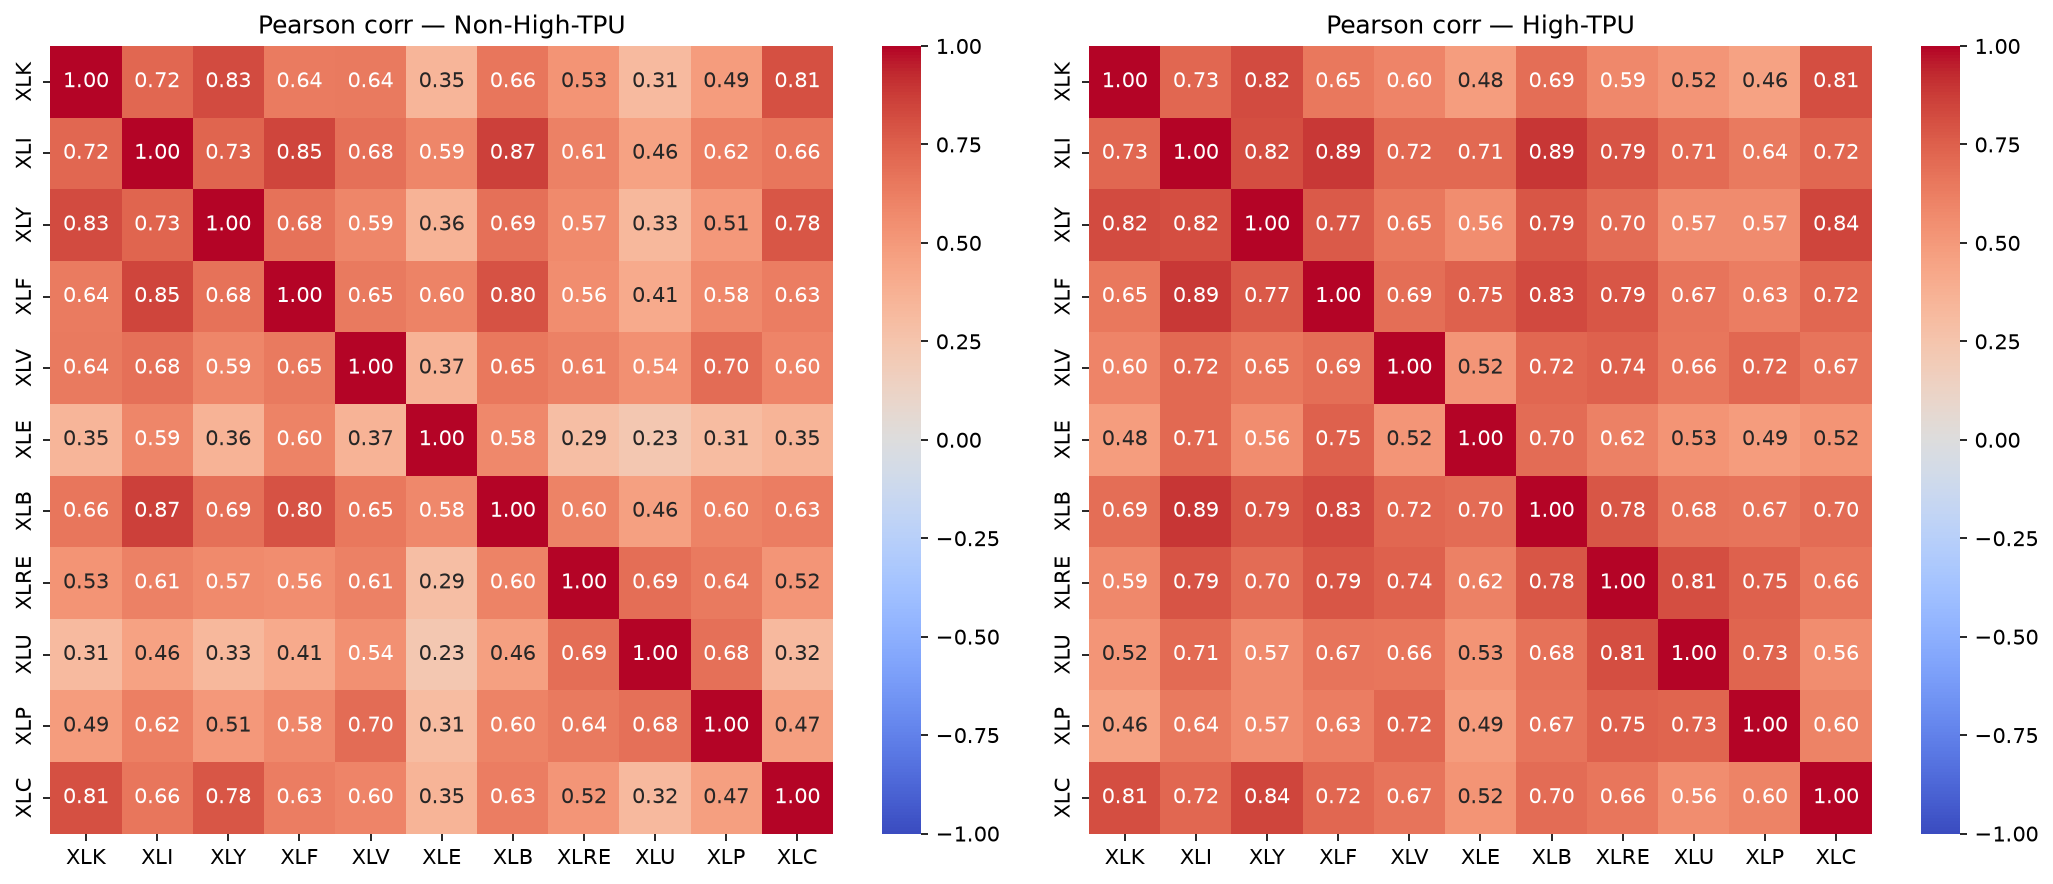

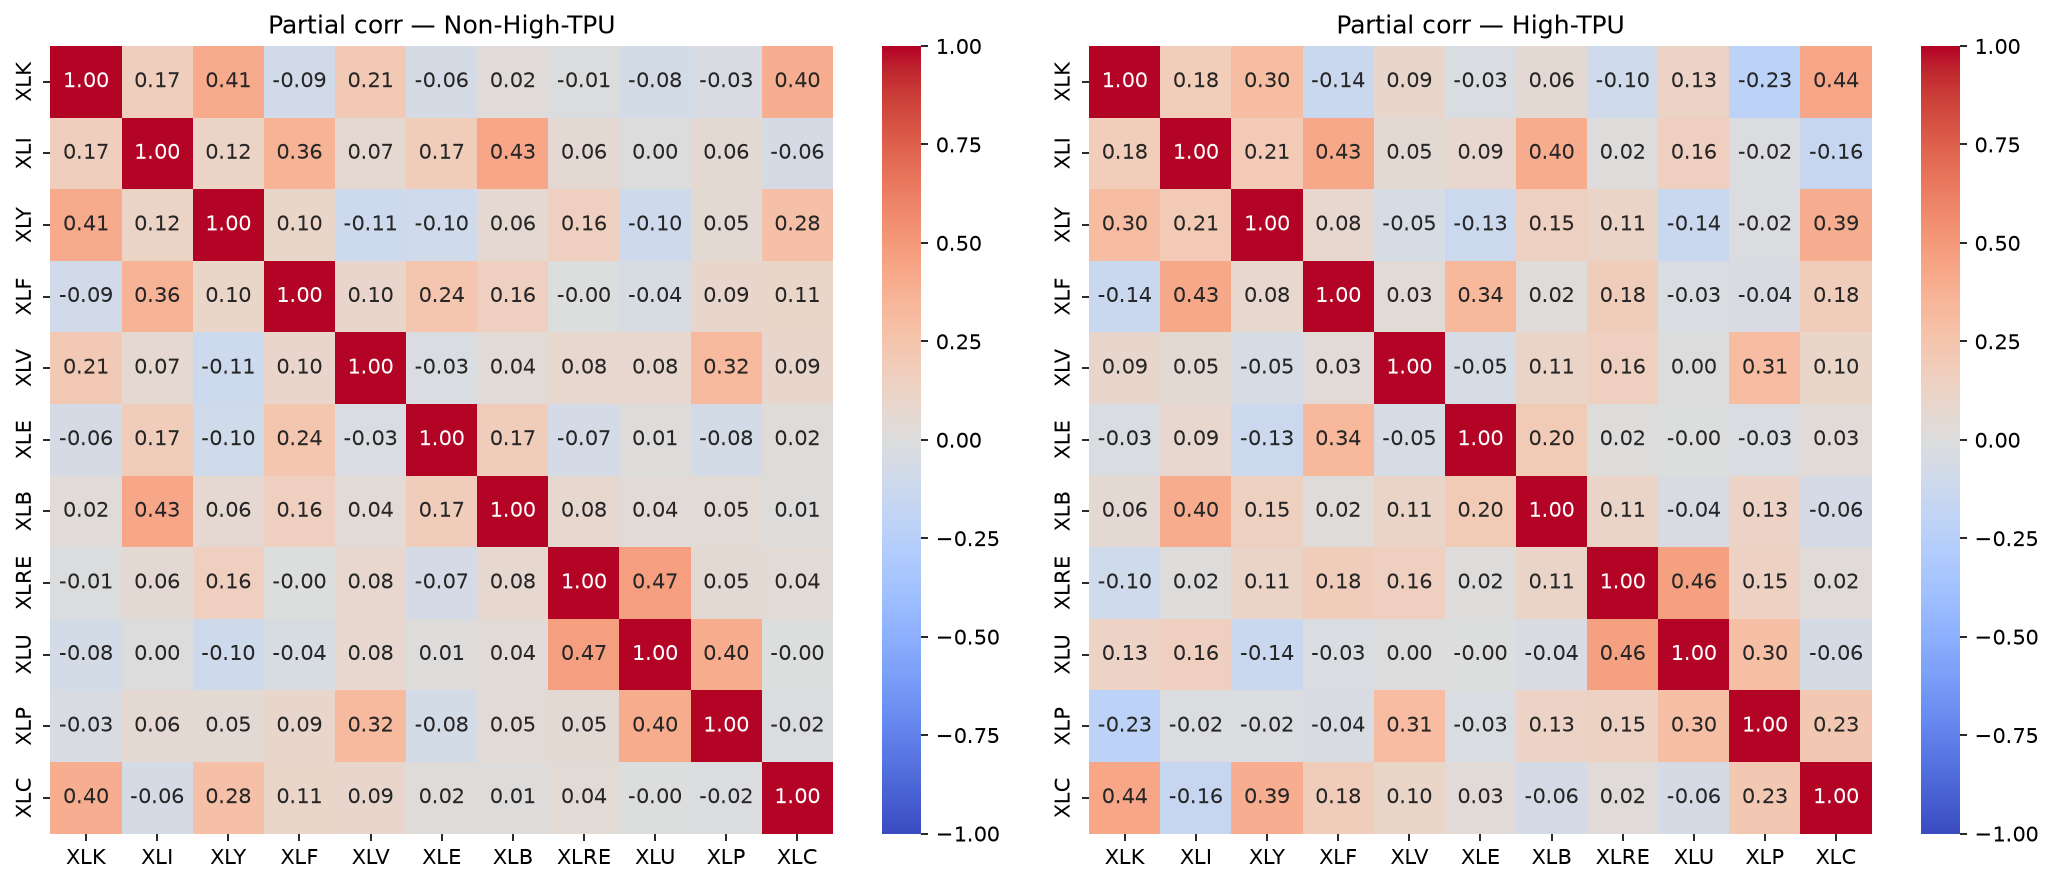

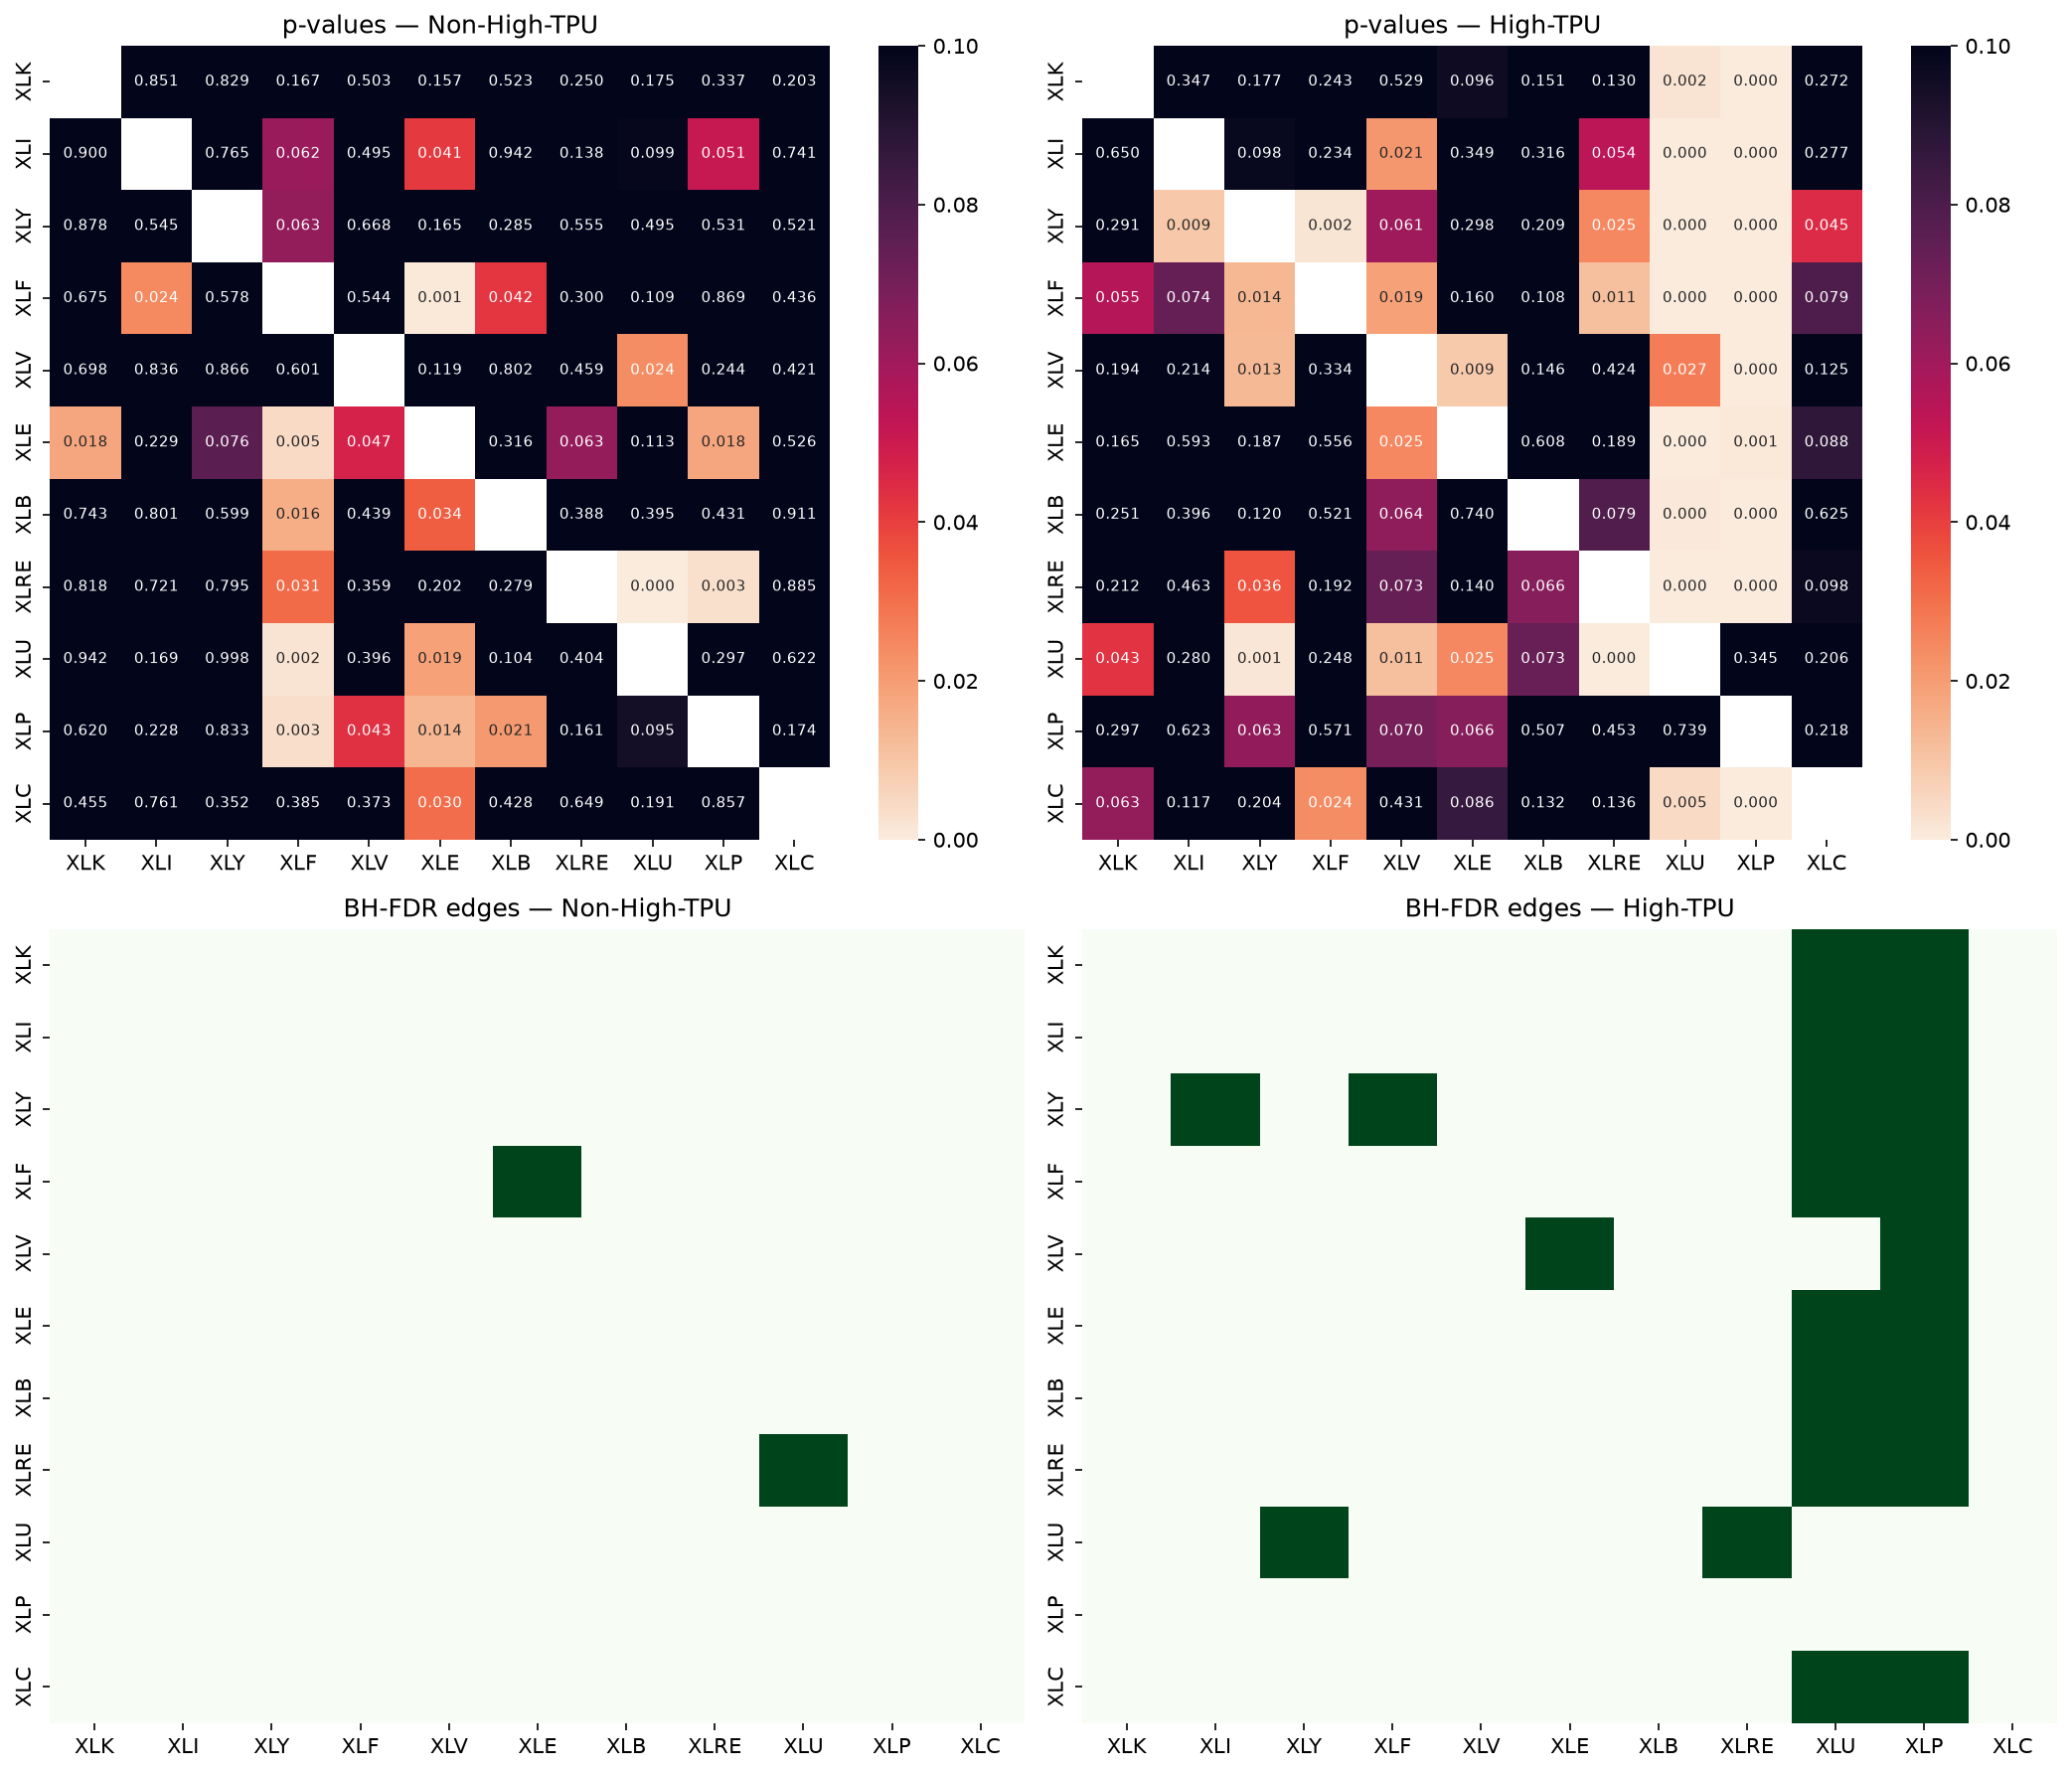

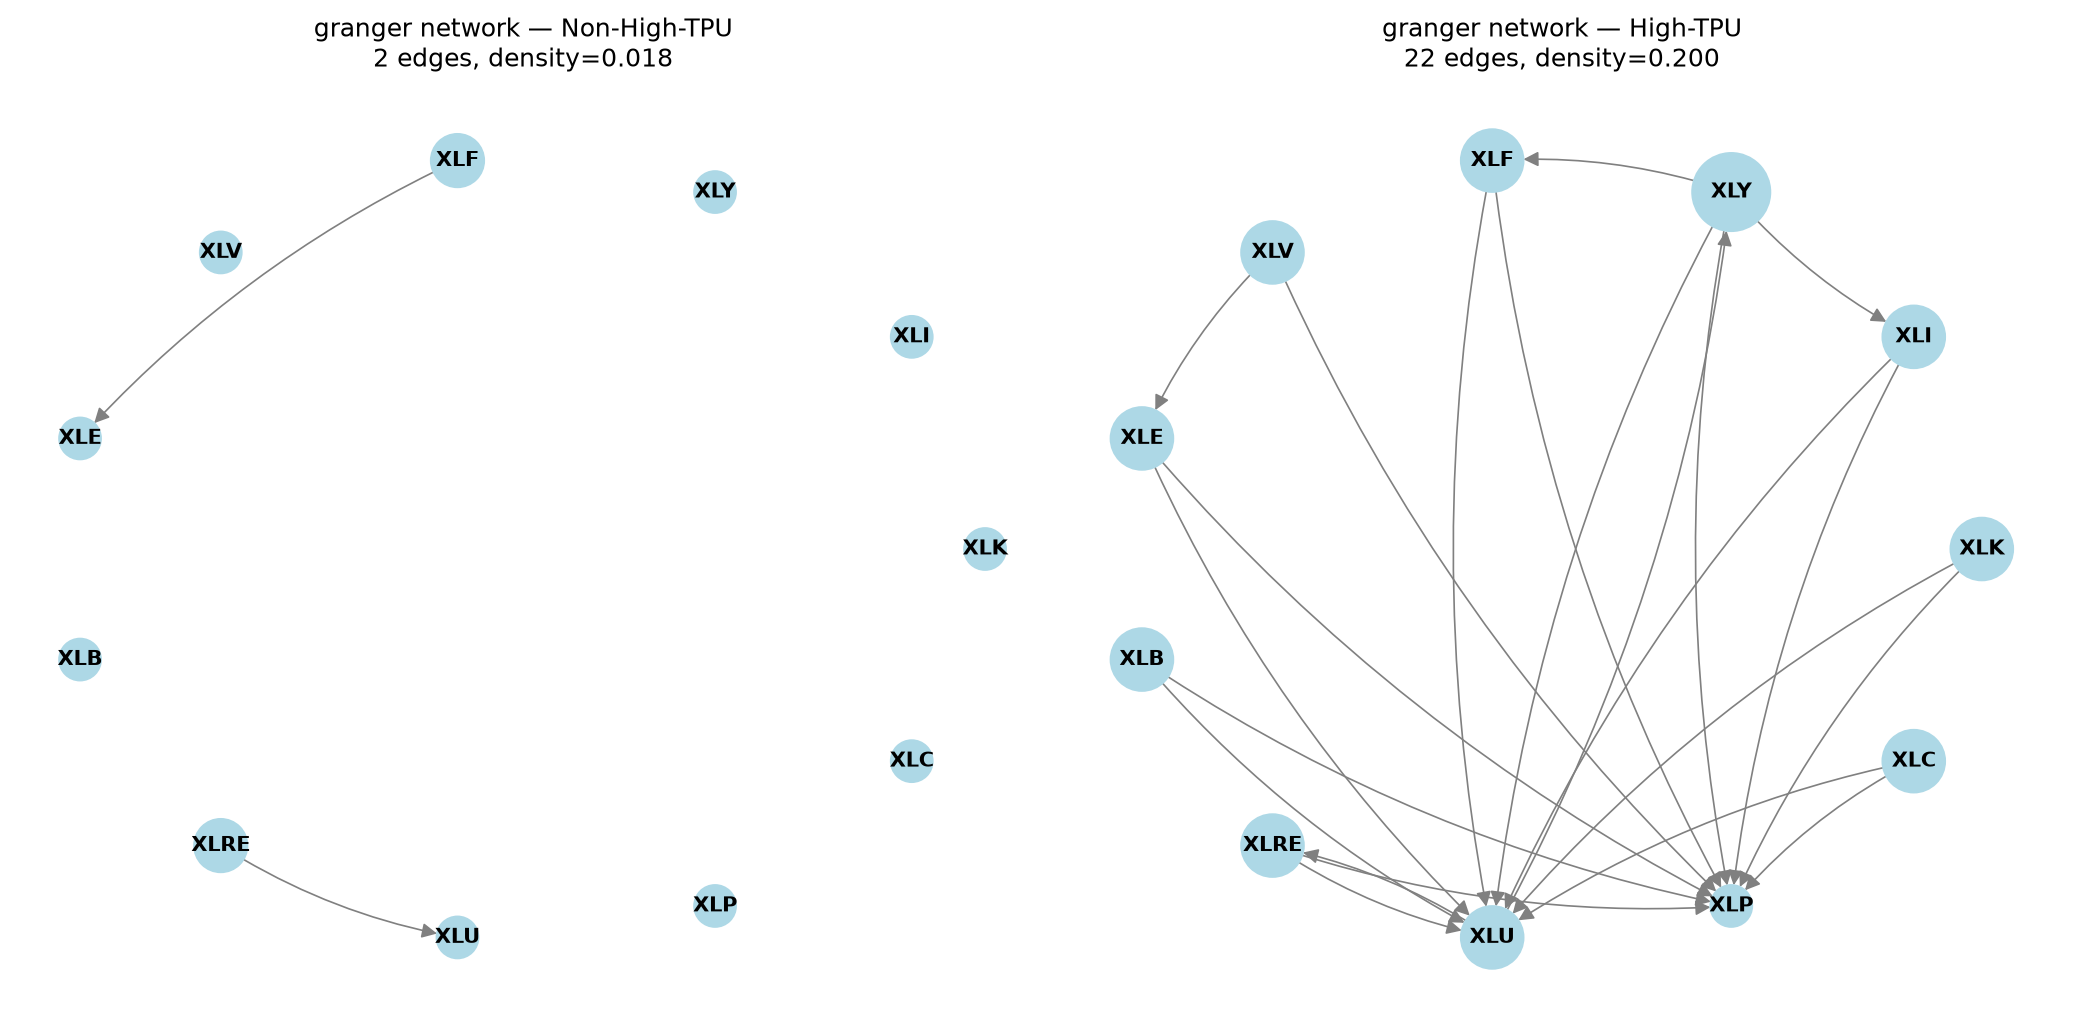

In [5]:
from IPython.display import Image, display

print("centrality — Non-High-TPU")
display(ci.metrics_low.sort_values("in_degree", ascending=False))
print("\ncentrality — High-TPU")
display(ci.metrics_high.sort_values("in_degree", ascending=False))

display(Image(filename=str(ci.out_dir / "corr.png")))
display(Image(filename=str(ci.out_dir / "pcorr.png")))
display(Image(filename=str(ci.out_dir / "granger.png")))
display(Image(filename=str(ci.out_dir / "networks.png")))

## Network Estimation

In this sections we aim to compare the structure between the two TPU regimes. We used the purged returns from the previous step as the input to this part because is already controlled for VIX and the rate spread. We solve the question regarding if 11 sectors is really different when the market is high or non-high TPU. 

We use 4 different graph measurement: 
1. Pearson correlation: Linear co-movement between pairs.
2. Partial correlation: Dependency betweeen two sectors after removing the effect of all others.
3. Granger causality: Directional predictability over time.
4. Network Metrics (degree, betweenness, PageRank, clustering): Structural properties of the resulting graph.
With these four let us makes a claim about TPU

#### Pearson and partial correlation 

It was computed the pearson correlation matrix between the 11 sectors. 
$$\rho_{ij} = \frac{Cov(\hat\varepsilon_i,\, \hat\varepsilon_j)}{\sigma_i \cdot \sigma_j}$$
Where $\hat\varepsilon_i$ are the purged returns of sector $i$ from the previous part. the move from -1 to 1 and we can see how two sectors move together. Also the **partial correlation** is the correlation between two sectors after removing the effect of all other sectors. it is important because if sector 'i' and 'j' move with sector 'k', then with the Pearson correlation it will be high but the partial correlation removes this indirect dependancy. In summary, if Pearson is high but partial is low, then the apparent co-movement is driven by common shocks and not by direct dependencies between the two sectors.

#### Grange causality 

The correlations that we saw are symmteric measurements, it means they treath both sectors equally. So for the direction of the dependenciees we use the **Granger causality** which test for directional predictability.Sector $i$ Granger-causes sector $j$ if the past values of $i$ help to predict $j$ beyond what the past of $j$ already predicts.
We fit two models for each ordered pair:

$$\text{restricted: } \hat\varepsilon_{j,t} = \sum_{k=1}^{p} \phi_k \, \hat\varepsilon_{j, t-k} + u_t$$
$$\text{unrestricted: } \hat\varepsilon_{j,t} = \sum_{k=1}^{p} \phi_k \, \hat\varepsilon_{j, t-k} + \sum_{k=1}^{p} \psi_k \, \hat\varepsilon_{i, t-k} + u_t$$

Then we run an F-test, If we reject the null then $i$ Granger-causes $j$ and we add a directed edge from $i$ to $j$. We use $p = 5$ which corresponds to one trading week of data, this is a standard horizon for short-term sector dependencies in daily financial data. Across 11 sectors we have $11 \times 10 = 110$ ordered pairs and we test all of them per regime, so in total we have 220 tests. A confounder that affects both sectors at the same time but with different lags can produce bad Granger relationships. That is why we did the backdoor adjustment in the previous part, so we reduce the contamination from common confounders, so the remaining Granger edges are cleaner indicators of sector to sector predictability.

#### Benjamini-Hochberg FDR correction

We expected approximated 5 false positives with the 110 test that we ran. just by the 5% significance. So we use this correctos to controls the expected fraction of false positives among rejected hypotheses- first we sort the p-values in ascending order and find the largest 'k' such that:
$$p_{(k)} \leq \frac{k}{110} \cdot q$$
And we reject all the hypotheses with rank less or equal to $k$. We use $q = 0.05$ as the FDR threshold. Each rejected hypothesis becomes a directed edge in the network of the corresponding regime

#### Network metrics

We used the library `networkx` in Python and compute these measurements: 
- **Density**: the fraction of possible edges that exist in the network.
- **In-degree**: the number of incoming edges to each sector
- **Out-degree**: the number of outgoing edges from each sector
- **Betweenness centrality**: the fraction of shortest paths in the network that pass through a node
- **PageRank**: the stationary distribution of a damped random walk on the graph
- **Clustering coefficient**: for each node, the fraction of pairs of its neighbors that are also connected to each other

#### Result 

The first thing we can notice is the density of the network. In Non-High-TPU only 2 edges out of 110 survive the FDR correction, this gives a density of 0.018. In High-TPU 22 edges survive, this gives a density of 0.200, so the network is around 11 times denser in the High-TPU regime. What is important is that is statistically strong because the hih-TPU regime has fewer observations 587 days vs 1419 days. so the Granger tests have less statistical power in this regime and it was still able to find more significant edges. So the dependencies are really strong. 

The pearson correlation shows that high-TPU goes up across sectors compared to non-high-TPU, basically 'correlations rise in a crisis'. On the other hand when using the partial correlation the values are much smaller, this confirms that most of the co-movement are driven by common shocks and not by directed sector to sector dependencies. This confirms that using the Granger as the real network structure and the pearon as noisies proxy. 

The big finding is in the High-TPU network. Looking at the centrality table of the High-TPU regime we can see that:
- **XLP** (Consumer Staples) has in-degree of 9 and out-degree of 0, so 9 out of the 10 other sectors Granger-cause XLP but XLP does not Granger-cause anyone. **pure absorber**.
- **XLU** (Utilities) has in-degree of 8 and out-degree of 2, and a betweenness of 0.333 which is the highest in the network. XLU is both an absorber and a relay station.
- **XLY** (Consumer Discretionary) has out-degree of 4 and betweenness of 0.183, so it is the main transmitter of the network.
- The cyclical and growth sectors (XLK, XLV, XLB, XLC) have out-degree of 2 and in-degree of 0, they are pure transmitters.

In high uncertainty regimes the information propagates from cyclical sectors towards the defensive ones (XLP and XLU). XLY appears as the leading transmitter because consumer discretionary returns are forward-looking and respond first to uncertainty shocks. 

The PageRank measurement confirms that XLP with 0.236 and XLU has 0.222, around 46% of the total PageRank mass of the network. Almost half of the information flow lands in the two most defensive sectors of the US equity market. In the Non-High-TPU regime we should not interpret the PageRank as an economic centrality measurement, the real finding is that the network is sparse with only 2 edges.

The clustering of XLP and XLU which are the absorbers is low (0.083 and 0.071), this means that the sectors that send signals to XLP and XLU are not strongly connected to each other. So basically is centralized towards the defensive sectors and not divided into multiple sectors. 

So basically we rely on multiple metrics and not just in one which makes our results strong. 



In [6]:
ci.run_coin_vecm()

Cointegration + VECM + Lag Sensitivity
8. johansen + VECM (lag diff=1)
   High-TPU: 587 obs
   rank (trace)   = 1
   rank (max-eig) = 1
   leaders (top 3 by |α|): XLRE=0.034, XLI=0.030, XLE=0.029
   Non-High-TPU: 1419 obs
   rank (trace)   = 1
   rank (max-eig) = 1
   leaders (top 3 by |α|): XLY=0.058, XLC=0.056, XLK=0.049
   lag sensitivity check (lags=[1, 2, 3])
     rank_low  rank_high
lag                     
1           1          1
2           1          1
3           1          1
Cointegration and VECM done


johansen — Non-High-TPU


,trace_stat,trace_crit_5pct,trace_reject,max_eig_stat,max_eig_crit_5pct,max_eig_reject
r<=0,292.077993,285.1402,True,75.666643,70.5392,True
r<=1,216.411351,239.2468,False,44.564614,64.5040,False
r<=2,171.846737,197.3772,False,39.578047,58.4332,False
r<=3,132.268689,159.5290,False,34.365284,52.3622,False
r<=4,97.903406,125.6185,False,25.304011,46.2299,False
r<=5,72.599394,95.7542,False,23.583041,40.0763,False
r<=6,49.016353,69.8189,False,17.104625,33.8777,False
r<=7,31.911729,47.8545,False,12.927592,27.5858,False
r<=8,18.984137,29.7961,False,10.975078,21.1314,False
r<=9,8.009060,15.4943,False,5.771378,14.2639,False



johansen — High-TPU


,trace_stat,trace_crit_5pct,trace_reject,max_eig_stat,max_eig_crit_5pct,max_eig_reject
r<=0,309.865844,285.1402,True,96.460322,70.5392,True
r<=1,213.405522,239.2468,False,58.404775,64.5040,False
r<=2,155.000747,197.3772,False,43.951838,58.4332,False
r<=3,111.048909,159.5290,False,30.484216,52.3622,False
r<=4,80.564692,125.6185,False,24.489984,46.2299,False
r<=5,56.074708,95.7542,False,21.737476,40.0763,False
r<=6,34.337232,69.8189,False,13.027691,33.8777,False
r<=7,21.309540,47.8545,False,8.652654,27.5858,False
r<=8,12.656887,29.7961,False,6.289581,21.1314,False
r<=9,6.367305,15.4943,False,3.759727,14.2639,False



cointegrating vector β — Non-High-TPU


,vec_1
XLK,1.000
XLI,0.226
XLY,-1.078
XLF,-0.014
XLV,-0.096
XLE,-0.291
XLB,0.267
XLRE,0.400
XLU,0.296
XLP,-1.249



cointegrating vector β — High-TPU


,vec_1
XLK,1.000
XLI,-3.011
XLY,-0.238
XLF,0.562
XLV,-0.340
XLE,0.181
XLB,1.731
XLRE,-4.064
XLU,0.671
XLP,2.303



lag sensitivity (cointegrating rank by lag)


,rank_low,rank_high
lag,,
1,1,1
2,1,1
3,1,1


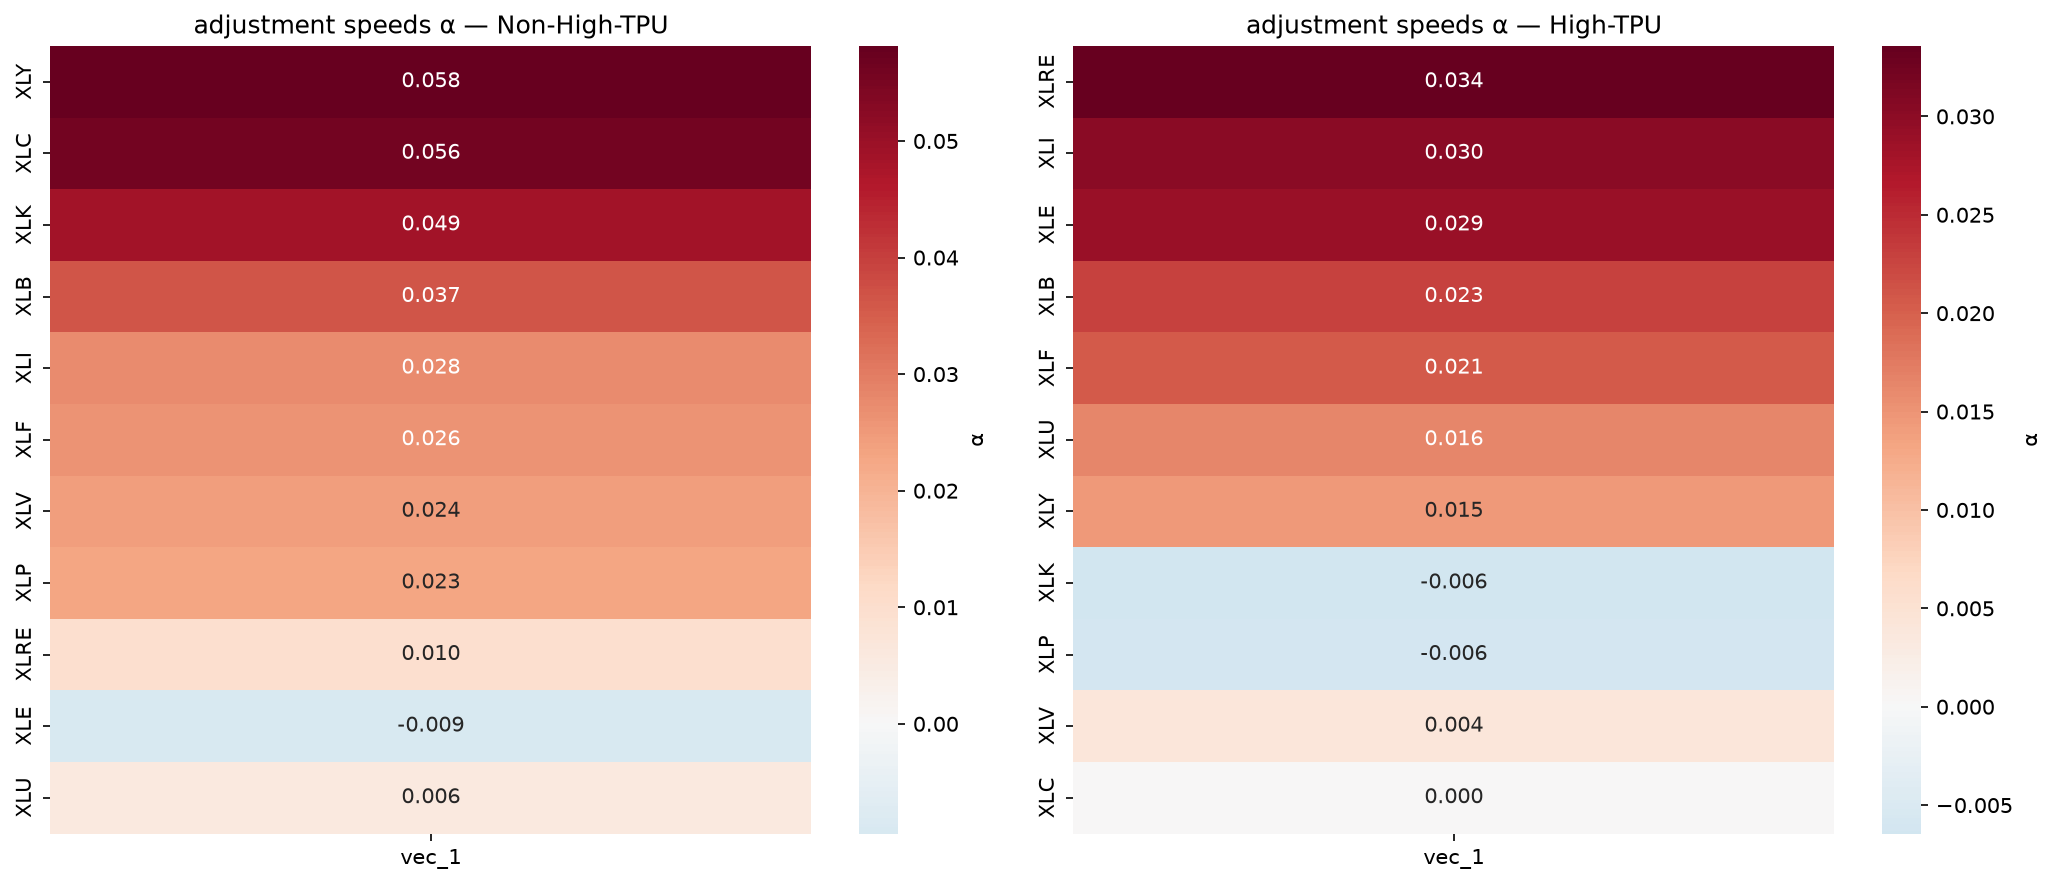

In [7]:
from IPython.display import Image, display
import pandas as pd

print("johansen — Non-High-TPU")
display(ci.coint_low)
print("\njohansen — High-TPU")
display(ci.coint_high)

print("\ncointegrating vector β — Non-High-TPU")
display(pd.DataFrame(ci.vecm_low.beta, index=ci.SECTORS, columns=["vec_1"]).round(3))
print("\ncointegrating vector β — High-TPU")
display(pd.DataFrame(ci.vecm_high.beta, index=ci.SECTORS, columns=["vec_1"]).round(3))

print("\nlag sensitivity (cointegrating rank by lag)")
display(ci.lag_sensitivity)

display(Image(filename=str(ci.out_dir / "vecm_alpha.png")))

## Long-Run Equilibrium (Cointegration and VECM)

In this section we want to show the **long-term equilibrium** between the sectors and compare it across regimes. The Granger network from the previous part captures short-term predictability at one trading week, but markets also have long-run relationships like months or years. This part is complementary to the previous one to answer which sectors are move together over time and which ones drives the equilibrium. 

We use the **log-prices** (not the returns) because cointegration needs non-stationary series and log-returns are stationary- We split the log-prices by regime using the TVTP-HMM and run 2 methods per regime: 
1- Johansen test: How many long run equilibrium relationships exist between all the 11 sectors.
2. VECM (Vector Error Correction Model) Estimate speed at which it corrects to equilibrium and the structure of equilibrium. 

#### Johansen test

Two non-stationary series are **cointegrated** if a linear combination of them is stationary. The Johansen test estimates how many of these cointegrating relationships exist between the 11 sectors. The number is called the **cointegrating rank** $r$ and it can be between 0 and 10. 
- **Trace statistic**: tests $H_0: r \leq i$ vs $H_1: r > i$ sequentially for $i = 0, 1, 2, \ldots$
- **Maximum eigenvalue statistic**: tests $H_0: r = i$ vs $H_1: r = i + 1$

We reject the null if the statistic exceeds the 5% critical value. the cointegrating rank is the number of successive rejections. 

#### VECM 

With the rank we can fit the VECM that models how the prices respond when they deviate from the equilibrium. 
$$\Delta p_t = \alpha \, \beta' \, p_{t-1} + \Gamma_1 \, \Delta p_{t-1} + \cdots + \varepsilon_t$$
Where: 
- $\beta$ is the **cointegrating vector** (positive means it moves with equilibrium), $\alpha$ is the **adjustment speed** (how fast it corrects to equilibrium),  $\Gamma_k$ matrices capture the short-run dynamics

And we run the test with different number of lags (k=1,2,3) to verify that the rank is robust to the lag choice. 

## Result 

The Johansen test gives us a cointegrating rank of 1 in both regimes. So there is one long-run equilibrium relationship between the 11 sectors in calm and in stress. But what is interesting is the strength of the statistics. The trace statistic at  r≤0  goes from 292.08 in Non-High-TPU to 309.87 in High-TPU and the max-eigenvalue goes from 75.67 to 96.46. Both are bigger in High-TPU, this means that the rejection of "no cointegration" is stronger under stress. So uncertainty does not destroy the long-run equilibrium. The lag sensitivity table confirms the robustness, the rank stays at 1 across lags 1, 2 and 3 in both regimes. So the result does not depend on the lag choice. 

From the **adjustment speeds** $\alpha$ we can see 2 things. First the average magnitude drops from around 0.029 in Non-High-TPU to around 0.019 in High-TPU, this means equilibrium is slower to restore under stress. Prices deviate further before going back. Second the **sectors that leads** changes between regimes. In Non-High-TPU the top sectors by $|\alpha|$ are XLY (0.058), XLC (0.056), XLK (0.049) and XLB (0.037), these are growth and tech sectors. In High-TPU the leaders become XLRE (0.034), XLI (0.030), XLE (0.029) and XLB (0.023), these are real-economy sectors. So in calm markets the price discovery is driven by growth sectors and in stress markets it shifts to the real economy (real estate, industrials, energy).

The **cointegrating vector** $\beta$ confirms the reorganization. Some sectors flip sign completely between regimes. XLI from +0.226 to -3.011, XLRE from +0.4 to -4.064 and XLP from -1.249 to +2.303. So the equilibrium becomes different. Basically the sectors that are in the long run relationship in calm markets are not the same sectors in stress markets. XLI dominates the high-TPU equilibrium with a huge negative weight. 

The combination of the two previous part gives us a two story about how TPU restructures the sector network. In the short tem, the network densifies and the defensive sectors XLP and XLU becomes absorbers. On the other hand in the long term, the equilibrium reorganizes and the real-economy sectors lead the price discovery (XLRE, XLI, XLE). In conclusion the short term absorbers (defensive sectors) anre not the long term leaders (enery, real state, etc). and this is consisten because defensive sectors react to short term shock but not drive the long run trajectory. 






### 7b. Supervised Learning

In [8]:
# Supervised learning analysis

### 7c. Unsupervised / Generative

In [ ]:
from src.models import HMMRegimeAnalysis

hmm = HMMRegimeAnalysis(smooth_window=10)
regime_df = hmm.run_analysis()


═════════════════════════════════════════════════════════════════
ADF STATIONARITY TESTS
═════════════════════════════════════════════════════════════════
  log(TPU) levels           | p=0.0743 | ADF= -2.699 | I(1) ✗  (near-unit-root)
  Δlog(TPU) raw             | p=0.0000 | ADF=-16.613 | I(0) ✓
  VIX levels                | p=0.0000 | ADF= -5.100 | I(0) ✓
═════════════════════════════════════════════════════════════════

Model estimation...
  [log(TPU) univariate | k=2] LL/obs=-2188.483  AIC=8,784,581.1  BIC=8,784,614.7


Model is not converging.  Current: -4301.405985376251 is not greater than -4301.405985145693. Delta is -2.3055781639413908e-07


  [log(TPU)+VIX bivariate | k=2] LL/obs=-4301.406  AIC=17,265,867.6  BIC=17,265,934.9
  [log(TPU) univariate | k=3] LL/obs=-2066.721  AIC=8,295,843.9  BIC=8,295,911.2


Model is not converging.  Current: -3589.617597861377 is not greater than -3589.617596873654. Delta is -9.877230695565231e-07


  [log(TPU)+VIX bivariate | k=3] LL/obs=-3589.618  AIC=14,408,767.0  BIC=14,408,884.7

→ BIC-selected model: log(TPU) univariate (k=3)

════════════════════════════════════════════════════════════
REGIME DIAGNOSTICS (smoothed labels)
════════════════════════════════════════════════════════════
  Mid-TPU: 920 days (45.8%)
  High-TPU: 575 days (28.6%)
  Low-TPU: 512 days (25.5%)

Spell durations:
  Low-TPU : avg 46.5 days  (max 128 days)
  Mid-TPU : avg 76.7 days  (max 657 days)
  High-TPU: avg 287.5 days  (max 404 days)
── EMISSION MEANS (log(TPU) original scale) ──
  State 0 [Low-TPU   ]: log(TPU)=5.2819 → TPU≈196.7
  State 1 [Mid-TPU   ]: log(TPU)=5.9976 → TPU≈402.4
  State 2 [High-TPU  ]: log(TPU)=7.0904 → TPU≈1200.4

── TRANSITION MATRIX ──
  P(Low-TPU→Low-TPU)=0.9634  P(Low-TPU→Mid-TPU)=0.0366  P(Low-TPU→High-TPU)=0.0000
  P(Mid-TPU→Low-TPU)=0.0191  P(Mid-TPU→Mid-TPU)=0.9784  P(Mid-TPU→High-TPU)=0.0025
  P(High-TPU→Low-TPU)=0.0000  P(High-TPU→Mid-TPU)=0.0022  P(High-TPU→High-TPU)=0

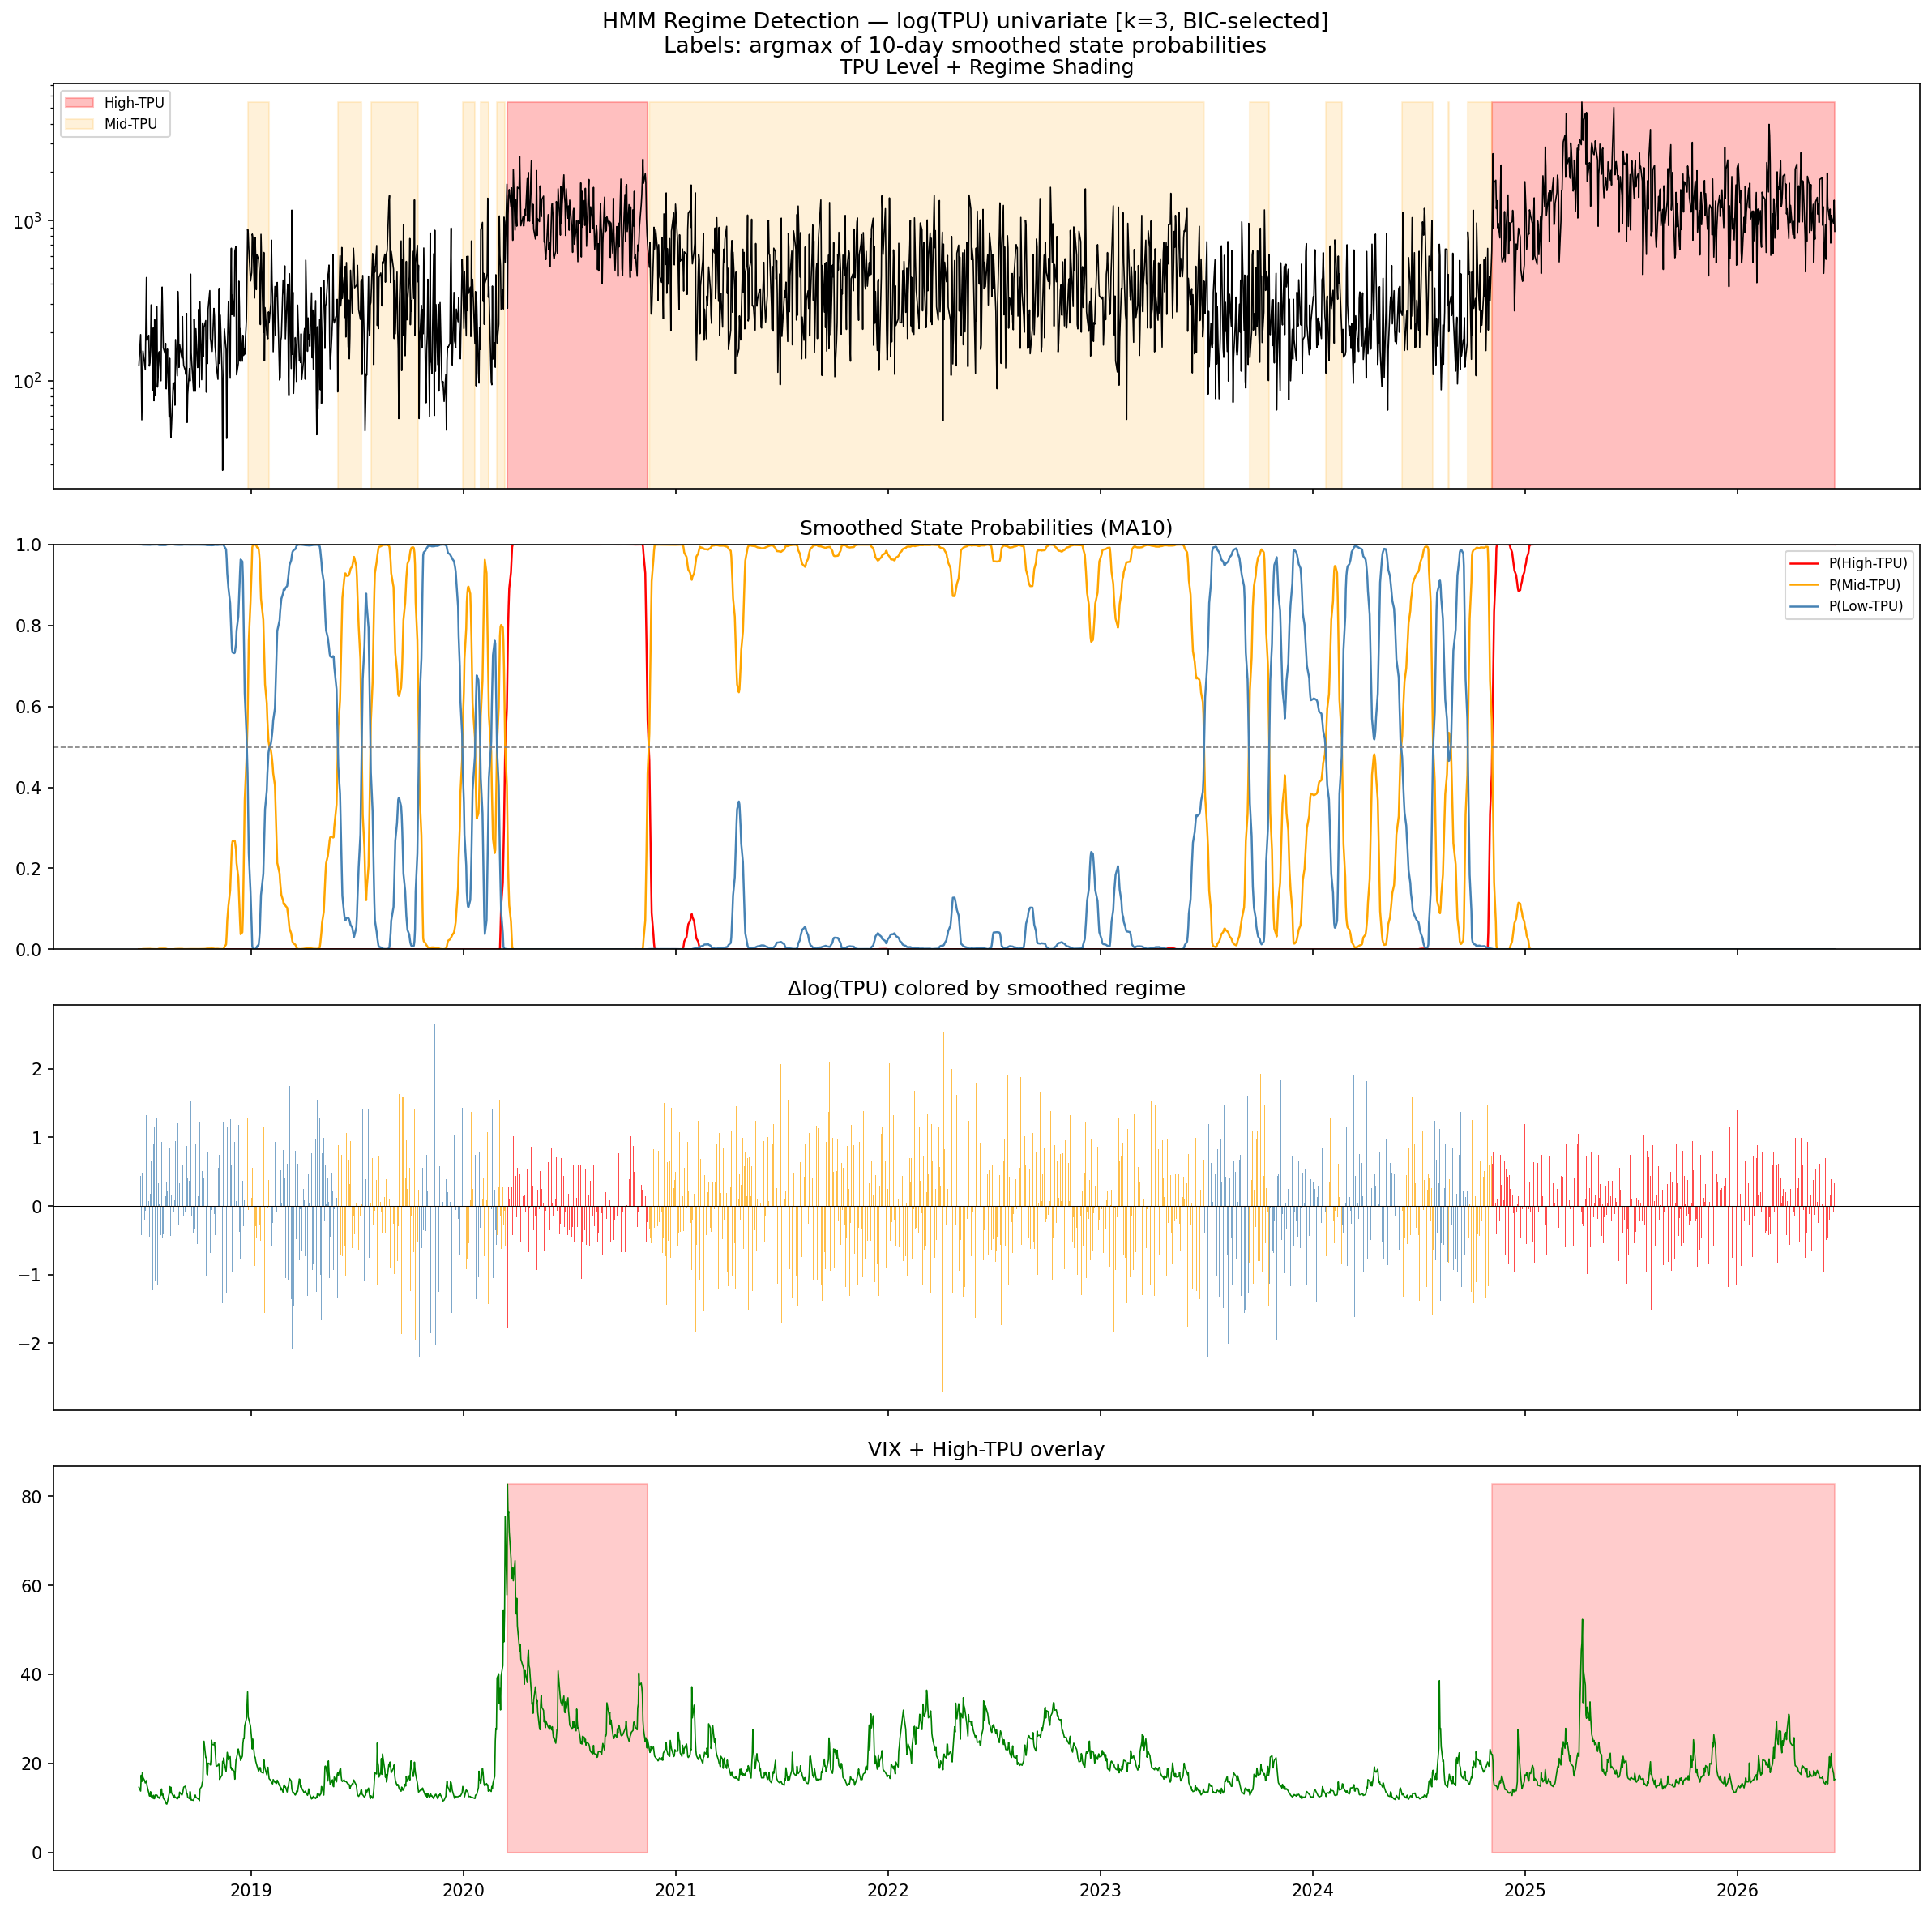

In [2]:
from IPython.display import Image, display

display(Image(filename=str(hmm.data_dir / "hmm_regime_plot.png")))

## Interpreting the HMM regime-detection results

### Why use log(TPU) in levels despite the ADF test (p = 0.0743)?

The ADF test on `log(TPU)` levels returns p = 0.0743 — technically not significant
at the 5% threshold, so the series is **not formally stationary** (near-unit-root,
borderline I(1)). This might look like a contradiction: why feed a non-stationary
series into the model as the regime-defining variable?

The reason is that **stationarity in the ADF sense is a requirement for models like
VAR/OLS, not for a Hidden Markov Model used for regime detection.** An HMM does not
assume the observed series has a constant unconditional mean — it explicitly models
the mean as **state-dependent**, switching between Low/Mid/High-TPU regimes. What
looks like a unit root in a single-regime ADF test is, structurally, a sequence of
distinct local means (regimes) rather than a stochastic trend. The ADF test cannot
distinguish between these two cases because it assumes one single regime throughout
the sample.

The model's own output supports this regime-switching interpretation over a "spurious
trend" explanation:
- The three emission means are economically distinct and well separated
  (TPU ≈ 197, 402, 1200), not a smooth drift.
- The transition matrix is **strongly persistent but not absorbing**
  (diagonal ≈ 0.96–0.998), consistent with genuine regimes rather than a one-way trend.
- Regimes alternate **bidirectionally**: 13 transitions toward higher regimes vs.
  11 toward lower ones, and Low-/Mid-TPU each occur in **more than 10 separate
  episodes** — a pure trend would not revisit the low regime repeatedly.
- The two High-TPU episodes line up with the two major trade-policy escalation
  windows in the sample (2020 and 2024–2026), which is an external, qualitative
  validation check independent of the ADF test.

`Δlog(TPU)` (the first difference) is indeed stationary (p ≈ 0.0000) and is reported
precisely as a robustness benchmark — but it answers a different question (*is the
daily change in uncertainty mean-reverting?*) than the one this model is built to
answer (*what discrete regime is uncertainty currently in?*). Differencing the series
would remove the level information that defines the regimes themselves, which is the
opposite of what we want here.

### Reading the diagnostics

- **BIC-selected model**: univariate `log(TPU)`, k = 3. Adding VIX as a second
  variable (bivariate) does **not** improve BIC despite a higher raw log-likelihood —
  the extra parameters aren't justified by the data. This means TPU alone is doing
  the work of separating regimes; VIX is correlated with but not necessary for the
  state assignment.
- **Regime persistence**: High-TPU has an expected duration of ~453 days and a
  long-run probability of 42.2% — once the system enters a high-uncertainty regime,
  it tends to stay there for a long time. This matches the plot: the two red bands
  (2020 COVID shock, 2024–2026 trade escalation) are wide, continuous blocks, not
  brief spikes.
- **VIX by regime**: mean VIX rises monotonically across regimes (15.3 → 20.7 → 22.9),
  with a much higher standard deviation in High-TPU (9.8 vs. 3.4 in Low-TPU) — High-TPU
  periods are not just higher on average, they're also more volatile and unstable.
- **Convergence warnings**: the `k=2` runs show "Model is not converging" messages
  with a negligible delta (~1e-7) — this is the EM algorithm hitting its numerical
  tolerance, not a real convergence failure. The k=3 model that was ultimately
  selected converged cleanly.

### Caveat to flag explicitly

Because `log(TPU)` is only borderline non-stationary by ADF, there's a residual risk
that part of what the HMM calls "High-TPU regime" reflects a slow-moving trend rather
than a sharp structural break. The bidirectional-transition check above is the main
defense against this risk, but it's worth stating openly in the writeup rather than
treating the regime labels as ground truth.

### Summary of Model Performance and Regime Interpretation

The analysis of the plot demonstrates that the Hidden Markov Model (HMM) effectively captures genuine, economically interpretable regimes rather than simple statistical trends. The findings can be summarized as follows:

*   **Regime Identification (Panel A & B):** The model successfully distinguishes between baseline uncertainty and acute crisis periods. It identifies a clear structural shift, with the TPU baseline rising significantly from the pre-2020 period to the 2024–2026 era. The probability states remain highly stable, showing sharp transitions and avoiding "hedging," while the 10-day smoothing effectively filters out transient noise.
*   **Volatilty and Dynamics (Panel C):** A crucial insight is that the "High-TPU" regime represents more than just higher index levels. The increased dispersion in Δlog(TPU) confirms that these periods are characterized by heightened volatility, which is a hallmark of genuine uncertainty regimes.
*   **External Validation (Panel D):** The model gains strong credibility through its alignment with the VIX. The fact that independent market-based fear gauges—specifically the 2020 and 2025 spikes—overlap with the "High-TPU" bands provides robust out-of-sample validation for the text-based policy index.

In [8]:
from src.models import HMM_TVTP

tvtp = HMM_TVTP()
tvtp.run_analysis()

════════════════════════════════════════════════════════════
Model                          LL    k        AIC        BIC
------------------------------------------------------------
Restricted (β=0)         -2,188.7    6    4,389.4    4,423.0
TVTP-HMM                 -2,183.2    8    4,382.3    4,427.2

LR test: LR=11.004 p=4.0785e-03 → REJECT H0 → VIX drives transitions
════════════════════════════════════════════════════════════


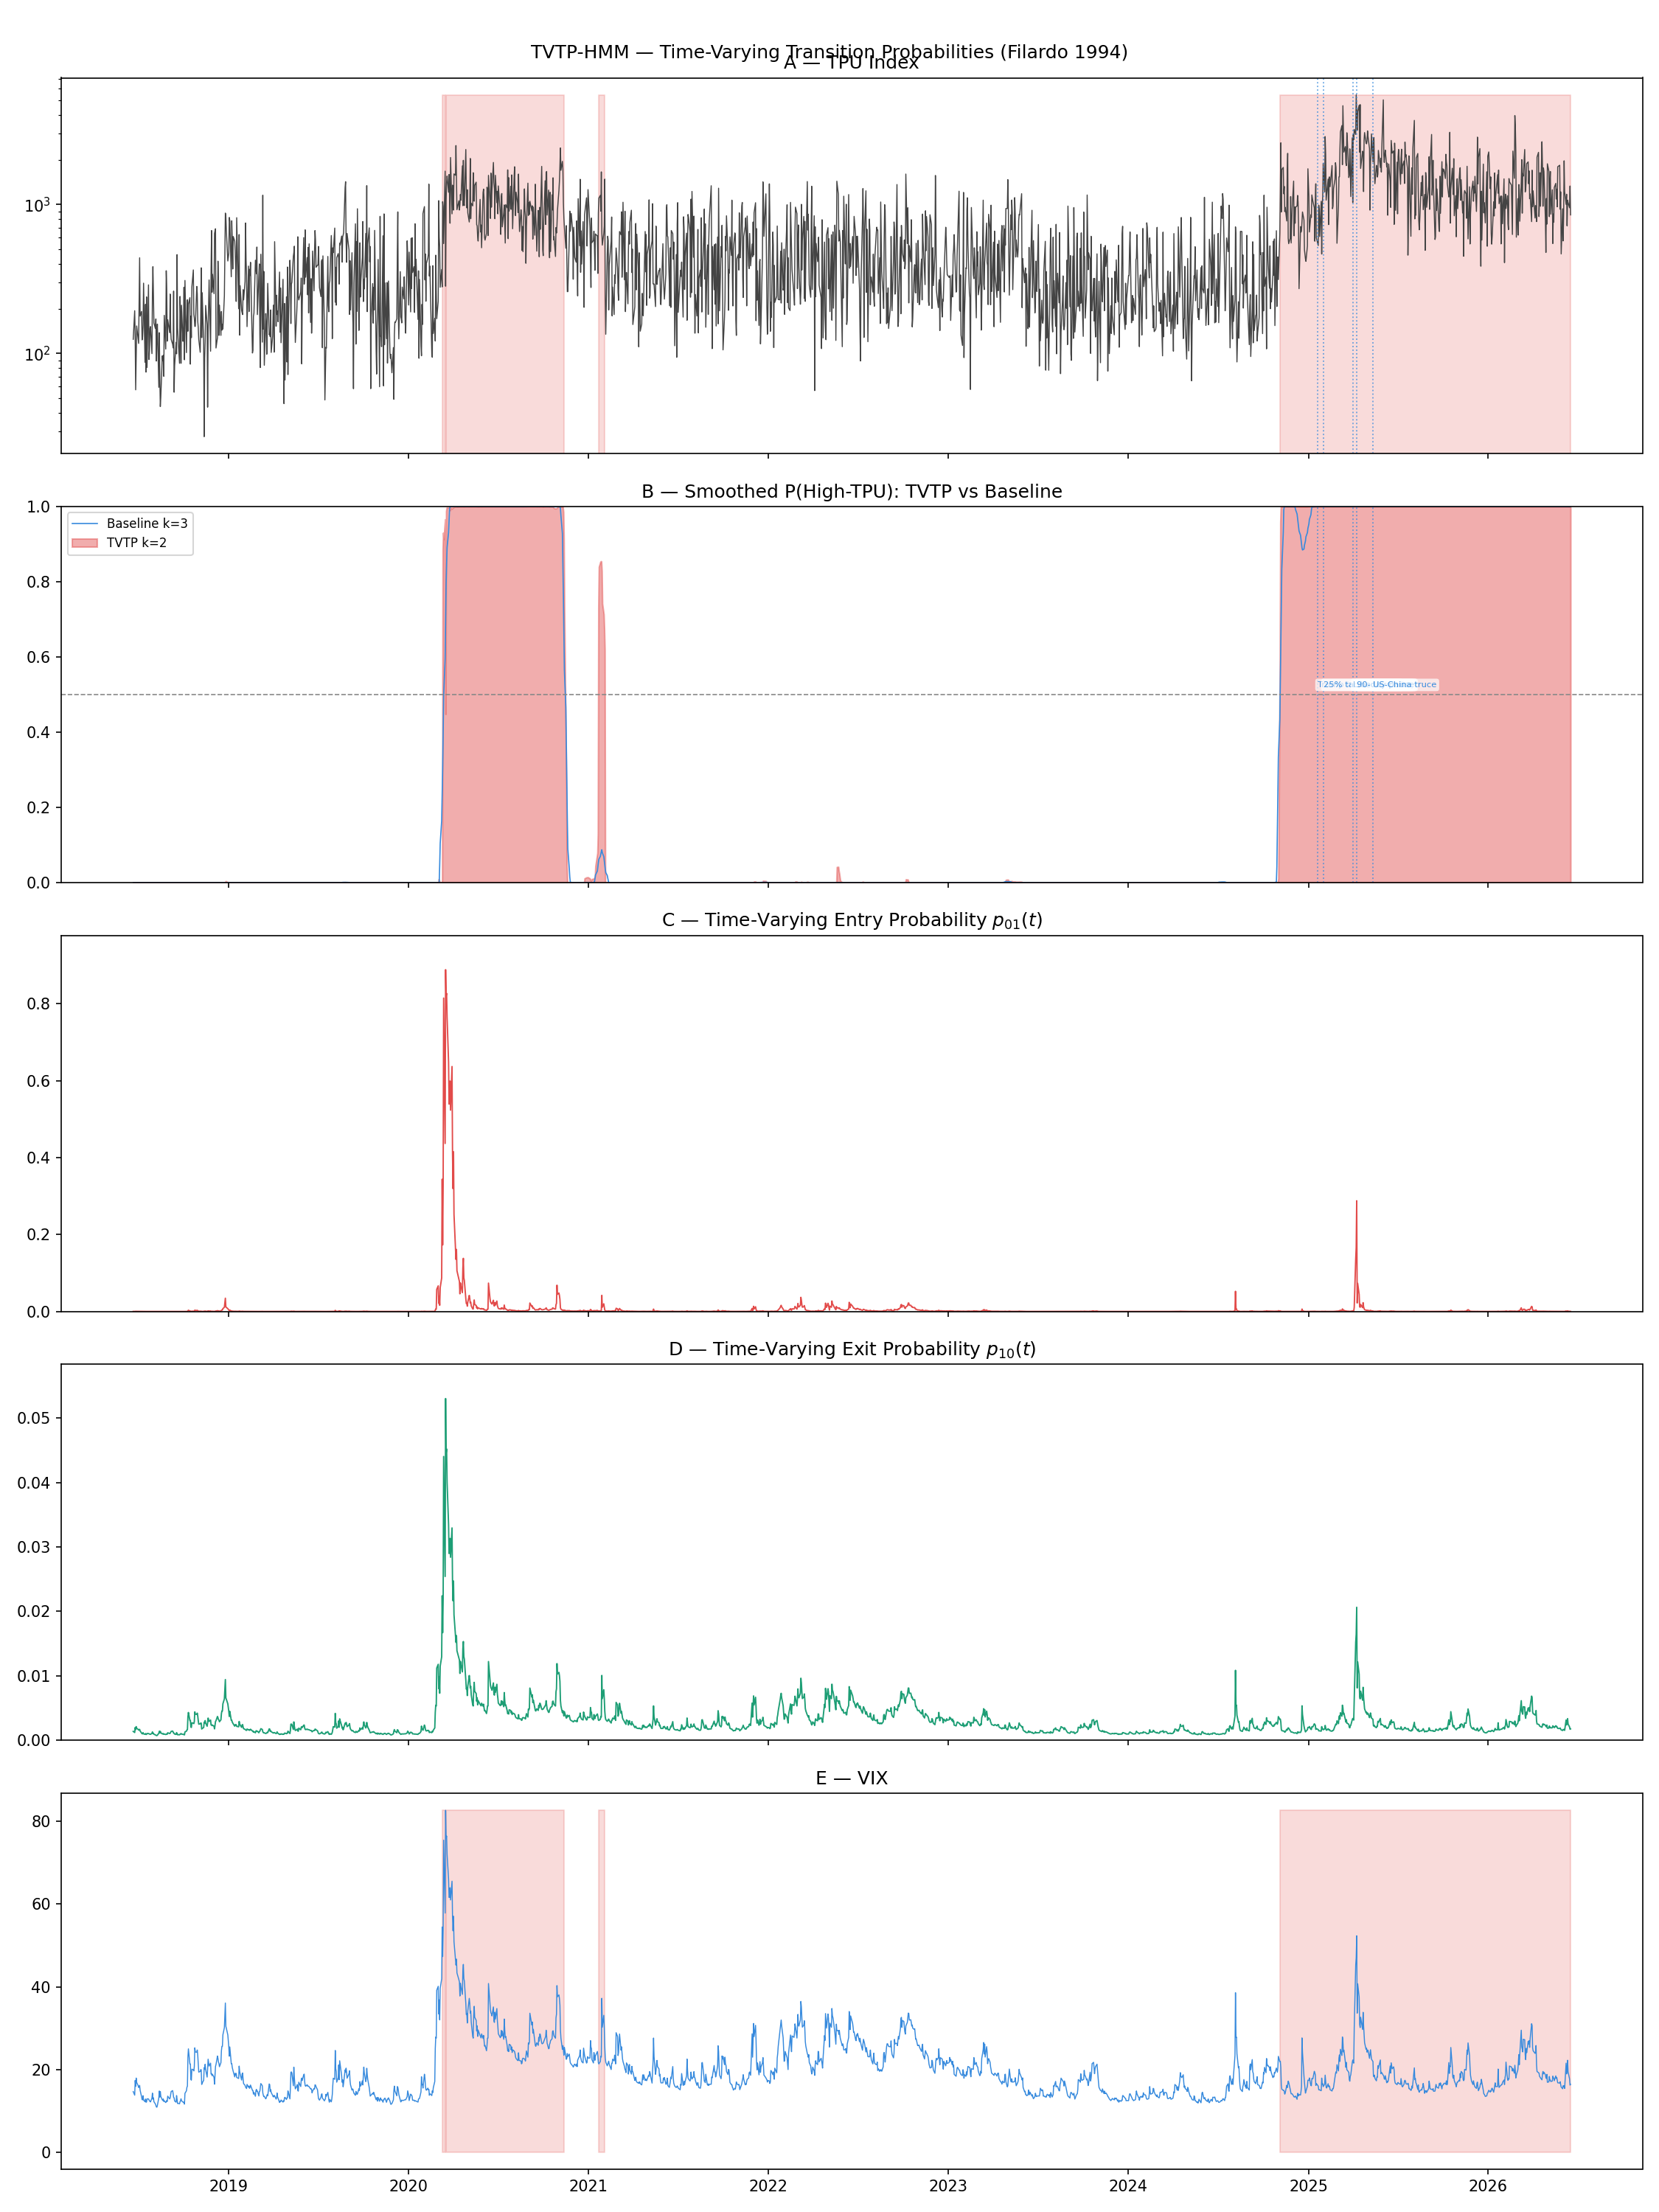

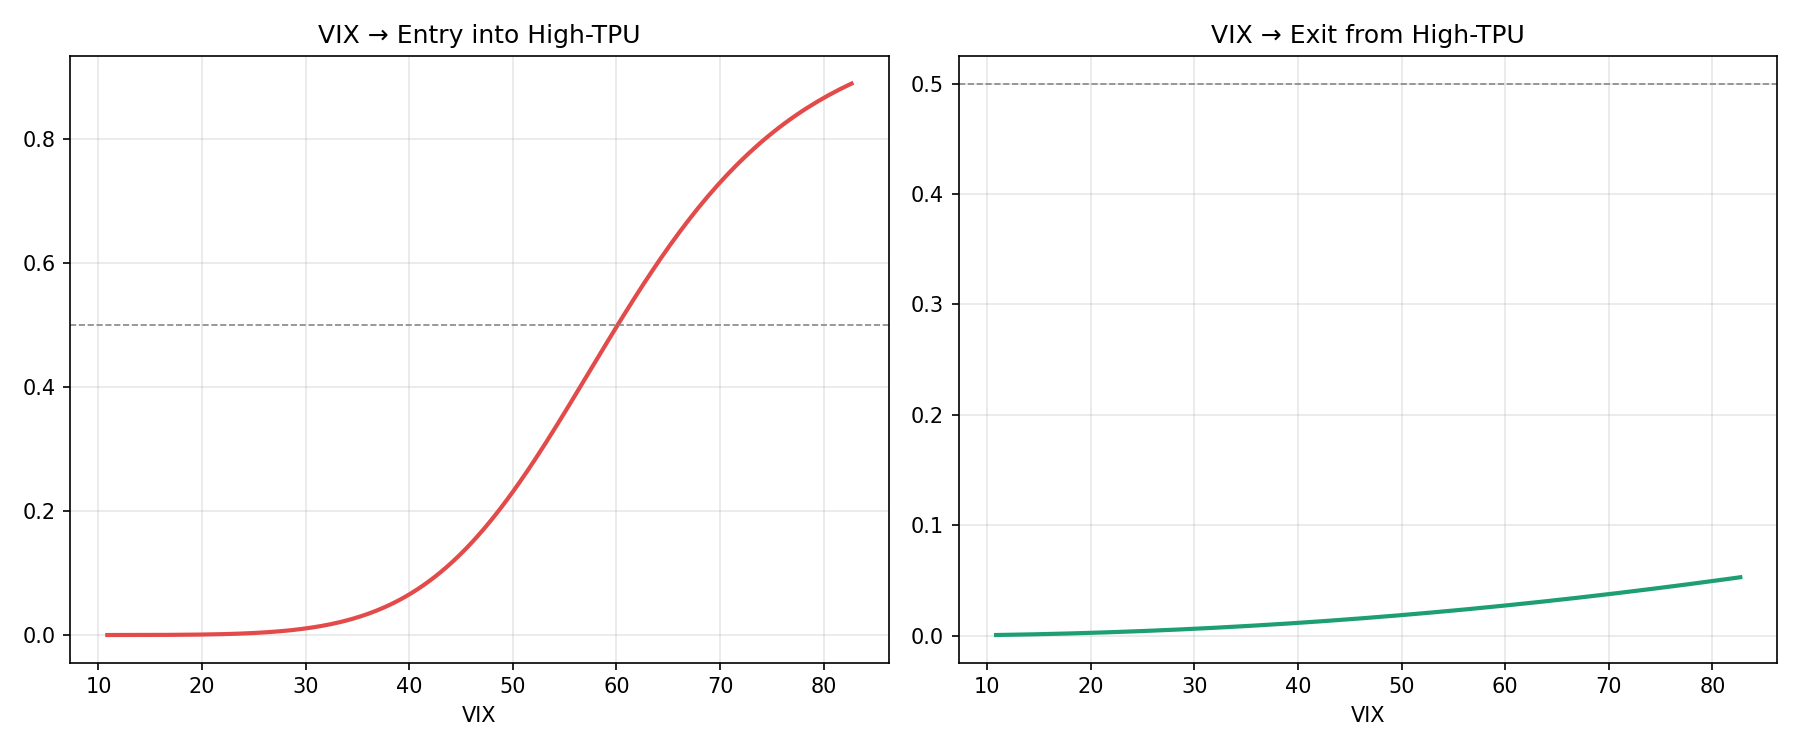

In [9]:
display(Image(filename=str(tvtp.out_dir / "tvtp_plots.png")))
display(Image(filename=str(tvtp.out_dir / "tvtp_vix_effect.png")))

markdown## TVTP-HMM Results: Interpretation

### Likelihood ratio test

The restricted model (β = 0, constant transition probabilities) yields LL = -2,188.7
with 6 parameters; allowing transition probabilities to depend on VIX (TVTP) raises
LL to -2,183.2 with 8 parameters. The likelihood ratio test rejects the null of
constant transitions (LR = 11.00, p = 0.0041), indicating that VIX has statistically
significant explanatory power over regime-switching dynamics, not just over the
regime levels themselves.

Note that AIC favors the TVTP model (4,382.3 vs. 4,389.4) while BIC favors the
restricted one (4,423.0 vs. 4,427.2). This divergence is expected: BIC penalizes
the two additional parameters (β₀₁, β₁₀) more heavily than AIC. Given the LR test is
the correct nested-model comparison here, and is significant, the TVTP specification
is preferred on conditional-dynamics grounds even though BIC alone would favor
parsimony.

### Panel-by-panel reading

**Panel A — TPU level.** Two High-TPU windows are flagged (2020, 2024–2026), plus
a brief third spike in early 2021 that is wide in panel A but only partially crosses
the 0.5 threshold in panel B — a short-lived uncertainty burst, not a sustained regime.

**Panel B — P(High-TPU): TVTP vs. baseline.** The TVTP (red) and static k=3 baseline
(blue) track each other closely in both magnitude and timing, including the
entry/exit edges of both major episodes. This convergence across two structurally
different models is a strong internal-validity check: regime identification is not
an artifact of one model's parameterization.

**Panels C–D — Entry/exit probabilities p₀₁(t), p₁₀(t).** Entry probability spikes
sharply at the onset of both major episodes (peaking near 0.85–0.9 in 2020), then
decays toward zero; exit probability stays uniformly low (<0.05) throughout, including
inside High-TPU windows. This asymmetry is the core finding: **transitions into
High-TPU are VIX-sensitive, transitions out are not** — once entered, the high-uncertainty
regime is exited on its own time scale regardless of VIX.

**Panel E — VIX with High-TPU overlay.** Both red bands contain a visible VIX spike,
reinforcing the entry-channel result. VIX spikes outside the bands (~2022, ~2024) that
don't trigger a regime shift are also consistent with the model: per panel C, entry
probability only becomes economically large above roughly VIX ≈ 50–60, so moderate VIX
spikes are correctly not classified as regime-triggering.

**VIX-effect curves (Image 2).** The entry curve is a steep logistic centered around
VIX ≈ 60: below ~35 entry probability is near zero, above ~70 it approaches 0.9. The
exit curve is nearly flat and stays under 0.05 across the full VIX range. This confirms
numerically what panels C–D show graphically: VIX governs *how uncertainty regimes begin*,
but plays essentially no role in *how they end*.

### Summary

The TVTP specification shows that elevated VIX raises the probability of entering a
High-TPU regime, consistent with market stress acting as an early signal or co-mover
of escalating trade-policy uncertainty. The lack of a symmetric VIX effect on exit
suggests regime persistence is driven by factors other than market volatility once
the uncertainty regime is established — plausibly the underlying policy process itself,
which does not unwind as quickly as market sentiment does.

## 8. Discussion & Conclusion *(complete for final submission)*

*Synthesise findings across all three method blocks. What does each lens reveal that the others miss? What are the limitations of your analysis?*


In [1]:
import pandas as pd

master = pd.read_csv("data/master_dataset.csv", index_col=0, parse_dates=True)
tvtp = pd.read_csv("data/phase_2/tvtp_regime_labels.csv", index_col=0, parse_dates=True)

print("=== master_dataset.csv ===")
print("Shape:", master.shape)
print("Columns:", list(master.columns))
print("Date range:", master.index.min(), "→", master.index.max())
print(master.head(2))
print()
print("=== tvtp_regime_labels.csv ===")
print("Shape:", tvtp.shape)
print("Columns:", list(tvtp.columns))
print("Date range:", tvtp.index.min(), "→", tvtp.index.max())
print("Regime counts:", tvtp["regime_label"].value_counts().to_dict())
print(tvtp.head(2))

=== master_dataset.csv ===
Shape: (2008, 26)
Columns: ['XLK', 'XLI', 'XLY', 'XLF', 'XLV', 'XLE', 'XLB', 'XLRE', 'XLU', 'XLP', 'XLC', 'vix', 'spread_10y2y', 'dff', 'tpu', 'XLK_rvol', 'XLI_rvol', 'XLY_rvol', 'XLF_rvol', 'XLV_rvol', 'XLE_rvol', 'XLB_rvol', 'XLRE_rvol', 'XLU_rvol', 'XLP_rvol', 'XLC_rvol']
Date range: 2018-06-21 00:00:00 → 2026-06-17 00:00:00
                 XLK       XLI       XLY       XLF       XLV       XLE  \
date                                                                     
2018-06-21 -0.007713 -0.012634 -0.007149 -0.002937 -0.005779 -0.018689   
2018-06-22 -0.003243  0.003449 -0.001705 -0.004791  0.004484  0.019755   

                 XLB      XLRE       XLU       XLP  ...  XLI_rvol  XLY_rvol  \
date                                                ...                       
2018-06-21 -0.010691  0.005949  0.003379  0.001955  ...       NaN       NaN   
2018-06-22  0.014458  0.008704  0.006920  0.008168  ...       NaN       NaN   

            XLF_rvol  XLV_rvo

# Causal Inference Section

This sections answered the question of how Trade Policy Uncertainty reestructures the network of the US sector ETFs after controlling for the broad market sttress measured by VIX and the rate spread.We used the short term directional dependencies with the Granger causality and the long term equilibrium with cointegration. 

#### Summary of findings

In the short term network there was a clear restructuring across the regimes, under non-high-TPU only 2 directed Granger edges survive the BH-FDR correction at q=0.05 and that gave a density of 0.018. On the other hand in high-TPU 22 edges survive and that gave a density of 0.200. The network became around 11 times denser when the market is in a high uncertainty regime. This is importan because the high TPU regime has fewer observations (587 agains 1419) and because of that it has less power, but it was able to still find more significant edges, so the dependencies are really strong. 

In the high TPU network is centralized. 4 metrics confirm this. the in-degree, betweennesss, PageRank and clustering coefficient. XLP has 9 in-degree, XLU has 8 in-degree and the highest betweenness of 0.333. They both capture arougn46% of the PageRank mass of the network. XLY which is consumer discretionary emerges as the main transmitter with 4 out-degree and 0.183 betweenness, this is consistent with empirical results that consumer discretionary leads the market under stress. 

the long term restructures but in a different way. The Johansen test gave a cointegrating rank of 1 in both regimes, but the rejection of "no cointegration" is statistically stronger under stress (statistic 309.87 vs 292.08, max-eigenvalue 96.46 vs 75.67) so uncertainty does not destroy the long run equilibrium, it makes it tighter. However the adjustment speed drops from around 0.029 to 0.019 on average, this means that under stress the equilibrium is stronger but slower to restore.

The way of leading the price discovery changes completely between regimes. In non high TPU the top sectors by  |alpha|  are XLY (0.058), XLC (0.056), XLK (0.049) and XLB (0.037), all growth or tech sectors. In high TPU the leaders become XLRE (0.034), XLI (0.030), XLE (0.029) and XLB (0.023), real economy sectors. The cointegrating vector confirms the reorganization, several sectors flip sign completely between regimes (XLI from +0.226 to -3.011, XLRE from +0.400 to -4.064, XLP from -1.249 to +2.303 as showing in the tables in the corresponding section). So the equilibrium is not just tighter under stress, it is a different equilibrium with different sectors. 

#### Differences in each perspective

The Granger network and the cointegration analysis show different sectors and this is important. The short term absorbers (XLP, XLU) are not the long term leaders (XLRE, XLI, XLE). If we only had the Granger network we can conclude that uncertainty restructures the market around defensive sectors. If we only had the cointegration we would conclude that uncertainty restructures the equilibrium around real economy sectors. Both are true but in different horizons so we have to pay attention to that.

Base on research, defensive sectors (XLP, XLU) react to short term shocks because investors move to them when uncertainty rises but they do not drive the long run trajectory of the market because they are non cyclical. Real economy sectors (XLRE, XLI, XLE) on the other hand manage the long run equilibrium because they reflect physical economic conditions that works during stress episodes (commodity prices, industrial production, real estate cycles).

The Pearson and partial correlation contrast adds another piece. Pearson correlations rise across all sectors under High TPU, but partial correlations are much smaller. That shows that most of the rising co-movement is driven by common shocks and not by direct sector to sector dependencies, which justifies using the Granger network as the real network structure and the Pearson as a noisier proxy.

#### Limitations of the analysis 

1. The Granger lag is fixed at p=5, one trading week, and the VECM at k=1, we did the VECM at k =1,2,3 but not the equivalent Granger.
2. Granger causality only captures linear dependencies, but under stress situations the relationships between sectors may be nonlinear.
3. High TPU have includes multiple episodes of situations like the 2020 COVID, 2022 inflation and the tariff these last 2 years. So the network and the equilibrium are weighted averages accros these episodes. An extension could be to estimate it separately, but the samplse size would be smaller.
4. Backdoor adjustment only uses VIX and rate spread but there could be another macroeconomic variables that could also confound the TPU (dollar inder, oil prices).
5. The regime classifications could be modified to include 3 regimes to strengthen the analysis.

## Conclusion 

TPU restructures the network of US sectors at both the short and long horizons. But that restructuring is not the same at both horizons because under high uncertainty the short term information flows in defensive sectors while on the long term it moves and stay around real economy sectors. This is something that is robust to the lag specification in the cointegration and survive multiple testing correction in the network estimation. This section provide a complement to the regime detection and to the predictive analysis. 

